# LSTM for Covariance Matrix

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

from gen_seq_data import SequenceDataset
from vech import vech, unvech

from torch.utils.data import Dataset, DataLoader
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import time

device = "mps" if torch.backends.mps.is_available() else "cpu"

## Price Data

In [2]:
tickers = "^GSPC BTC-USD GC=F"  # S&P 500 index
data = yf.download(tickers, period="max")

/var/folders/94/8_7g7dqx72760sk83dk1klgc0000gn/T/ipykernel_78884/2767321064.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="max")
[*********************100%***********************]  3 of 3 completed


In [3]:
data

Price              Close                                    High               \
Ticker           BTC-USD         GC=F        ^GSPC       BTC-USD         GC=F   
Date                                                                            
1927-12-30           NaN          NaN    17.660000           NaN          NaN   
1928-01-03           NaN          NaN    17.760000           NaN          NaN   
1928-01-04           NaN          NaN    17.719999           NaN          NaN   
1928-01-05           NaN          NaN    17.549999           NaN          NaN   
1928-01-06           NaN          NaN    17.660000           NaN          NaN   
...                  ...          ...          ...           ...          ...   
2026-03-18  71245.578125  4889.899902  6624.700195  74658.976562  4949.600098   
2026-03-19  69912.789062  4600.700195  6606.490234  71598.843750  4830.299805   
2026-03-20  70522.585938  4574.899902  6506.479980  71346.796875  4738.200195   
2026-03-21  68711.523438          NaN          NaN  71051.273438          NaN   
2026-03-22  68776.023438          NaN          NaN  69448.195312          NaN   

Price                             Low                                    Open  \
Ticker            ^GSPC       BTC-USD         GC=F        ^GSPC       BTC-USD   
Date                                                                            
1927-12-30    17.660000           NaN          NaN    17.660000           NaN   
1928-01-03    17.760000           NaN          NaN    17.760000           NaN   
1928-01-04    17.719999           NaN          NaN    17.719999           NaN   
1928-01-05    17.549999           NaN          NaN    17.549999           NaN   
1928-01-06    17.660000           NaN          NaN    17.660000           NaN   
...                 ...           ...          ...          ...           ...   
2026-03-18  6705.180176  70503.859375  4821.700195  6621.660156  73936.851562   
2026-03-19  6636.740234  68805.523438  4554.000000  6557.819824  71250.351562   
2026-03-20  6594.660156  69398.882812  4478.399902  6473.520020  69911.531250   
2026-03-21          NaN  68602.914062          NaN          NaN  70522.468750   
2026-03-22          NaN  68213.742188          NaN          NaN  68903.218750   

Price                                       Volume                          
Ticker             GC=F        ^GSPC       BTC-USD      GC=F         ^GSPC  
Date                                                                        
1927-12-30          NaN    17.660000           NaN       NaN  0.000000e+00  
1928-01-03          NaN    17.760000           NaN       NaN  0.000000e+00  
1928-01-04          NaN    17.719999           NaN       NaN  0.000000e+00  
1928-01-05          NaN    17.549999           NaN       NaN  0.000000e+00  
1928-01-06          NaN    17.660000           NaN       NaN  0.000000e+00  
...                 ...          ...           ...       ...           ...  
2026-03-18  4949.600098  6697.160156  4.622901e+10    1461.0  5.275480e+09  
2026-03-19  4830.299805  6583.120117  4.463143e+10     627.0  5.973390e+09  
2026-03-20  4653.899902  6594.660156  3.829908e+10  220773.0  7.040255e+09  
2026-03-21          NaN          NaN  2.110935e+10       NaN           NaN  
2026-03-22          NaN          NaN  2.806572e+10       NaN           NaN  

[25985 rows x 15 columns]

In [4]:
close = data["Close"].copy()

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

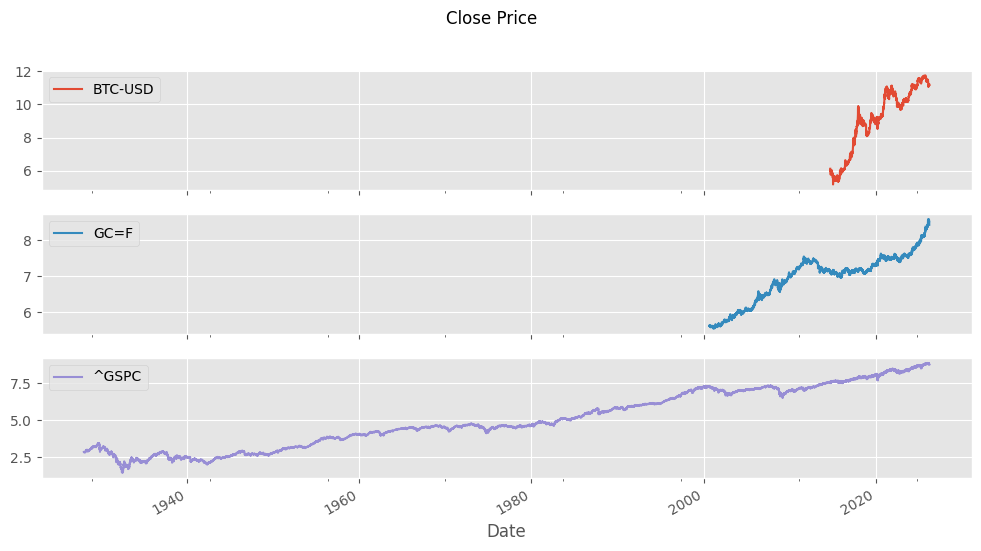

In [5]:
np.log(close).plot(title="Close Price", subplots=True, figsize=(12, 6))

In [6]:
logret = np.log(close).diff() # log(P_t) - log(P_{t-1})) = log(P_t / P_{t-1})

# Aufräumen: erste Zeile NaN durch diff, ggf. weitere NaNs durch Datenlücken
logret = logret.dropna()

logret.head(), logret.tail()

(Ticker       BTC-USD      GC=F     ^GSPC
 Date                                    
 2014-09-18 -0.074643 -0.007073  0.004879
 2014-09-19 -0.072402 -0.008521 -0.000477
 2014-09-23  0.080333  0.003446 -0.005793
 2014-09-24 -0.029306 -0.001968  0.007802
 2014-09-25 -0.027868  0.002131 -0.016301,
 Ticker       BTC-USD      GC=F     ^GSPC
 Date                                    
 2026-03-13  0.006713 -0.012451 -0.006078
 2026-03-17 -0.012617  0.001401  0.002491
 2026-03-18 -0.036884 -0.022466 -0.013701
 2026-03-19 -0.018884 -0.060963 -0.002753
 2026-03-20  0.008684 -0.005624 -0.015254)

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

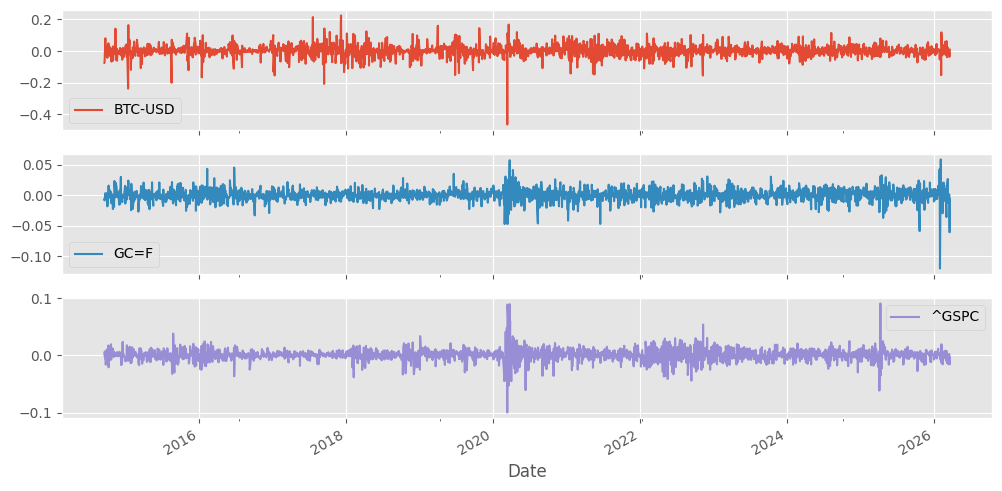

In [7]:
logret.plot(subplots=True, figsize=(12, 6))

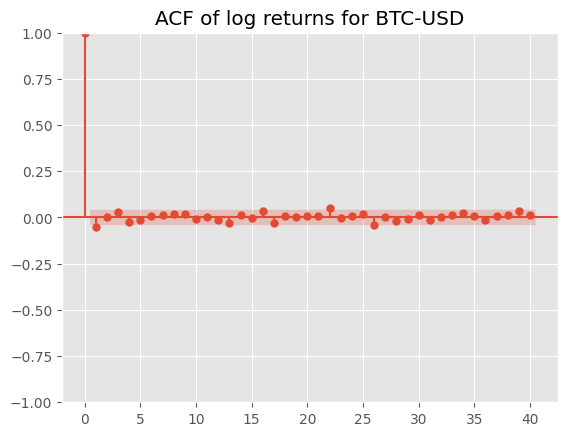

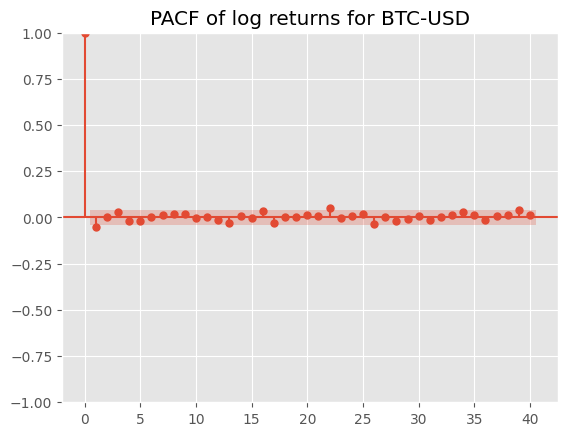

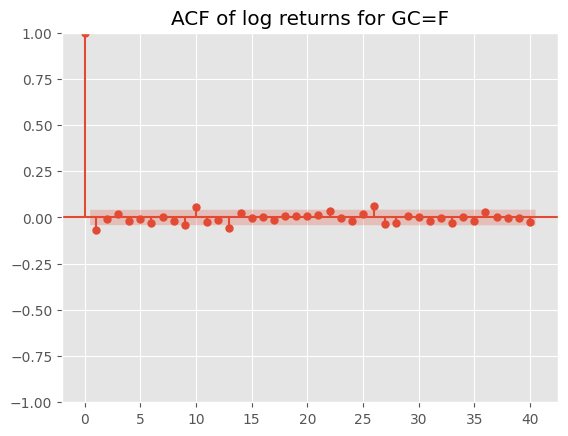

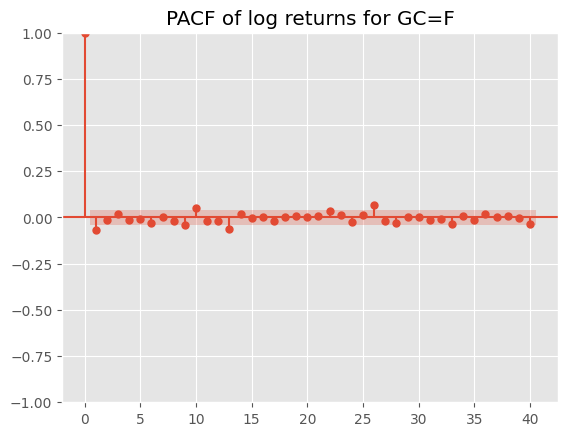

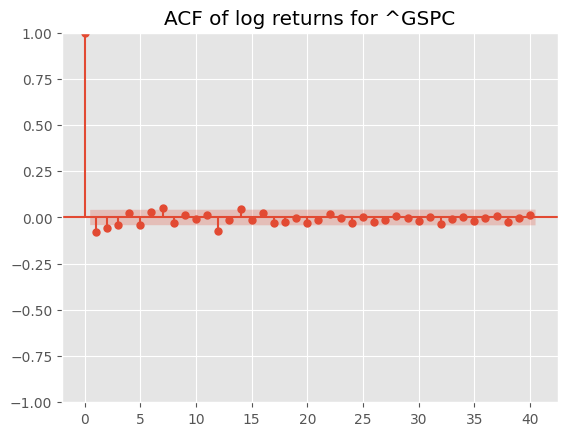

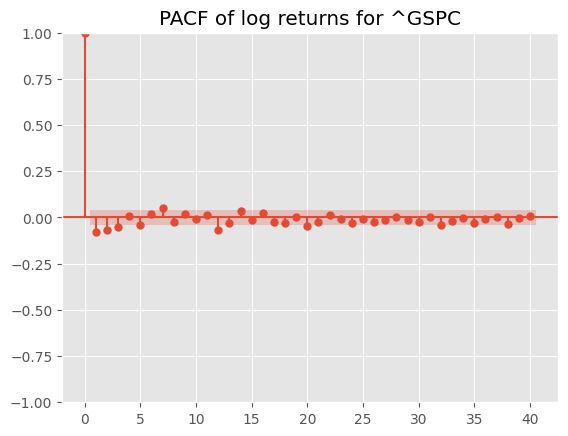

In [8]:
for col in logret.columns:
    plot_acf(logret[col], lags=40, title=f"ACF of log returns for {col}")
    plot_pacf(logret[col], lags=40, title=f"PACF of log returns for {col}")

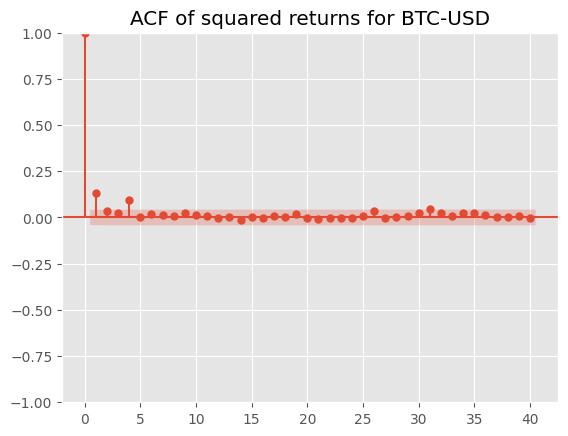

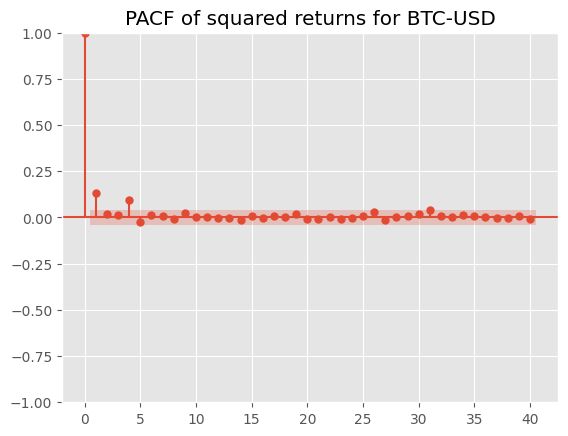

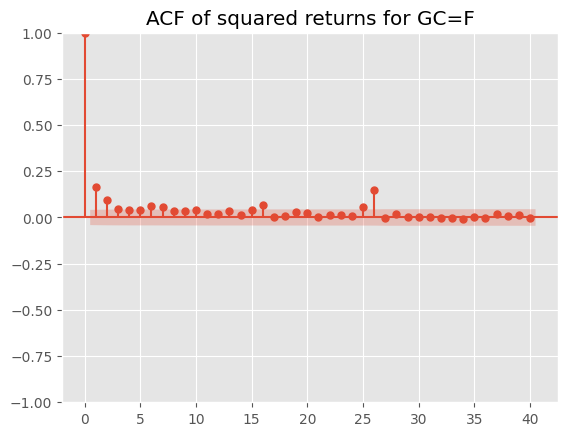

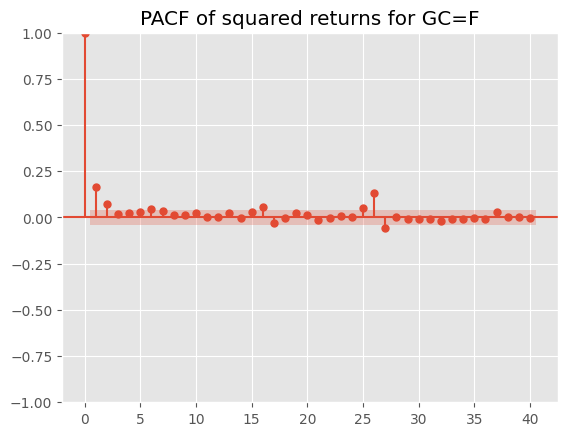

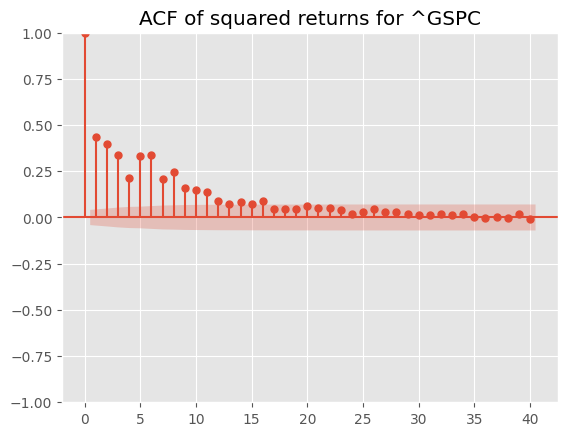

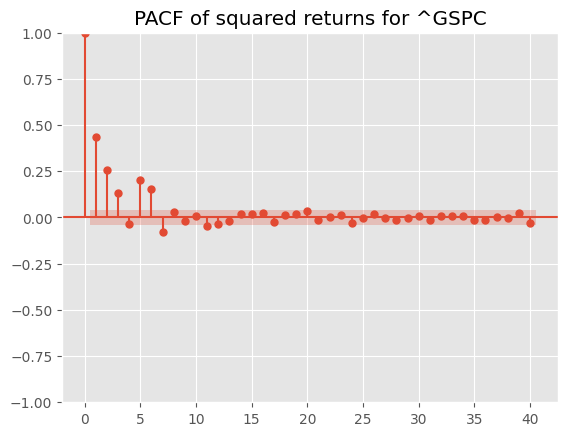

In [9]:
# squared returns
for col in logret.columns:
    plot_acf(logret[col]**2, lags=40, title=f"ACF of squared returns for {col}")
    plot_pacf(logret[col]**2, lags=40, title=f"PACF of squared returns for {col}")

In [10]:
from statsmodels.tsa.stattools import adfuller

for col in logret.columns:
    print(f"ADF test for {col}:")
    result = adfuller(logret[col])
    print(f"ADF statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("---")
    

ADF test for BTC-USD:
ADF statistic: -50.134828918637666
p-value: 0.0
---
ADF test for GC=F:
ADF statistic: -14.471679061428972
p-value: 6.589635416616967e-27
---
ADF test for ^GSPC:
ADF statistic: -13.192222703471977
p-value: 1.13797206728106e-24
---


In [11]:
feature_cols = tickers.split(" ")

In [12]:
R = logret[feature_cols].values.astype(np.float32)   # (N,d)

# Outer products pro t: (N,d,1) * (N,1,d) -> (N,d,d)
U = R[:, :, None] * R[:, None, :]

In [13]:
cross_returns = vech(torch.tensor(U))
cross_returns.shape

torch.Size([2259, 6])

In [14]:
logret.shape

(2259, 3)

In [15]:
input_data = np.concatenate([logret[feature_cols].values, cross_returns], axis=1)
input_df = pd.DataFrame(input_data, columns=feature_cols + [f"cross_{i+1}" for i in range(cross_returns.shape[1])])

In [16]:
logret.index

DatetimeIndex(['2014-09-18', '2014-09-19', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26', '2014-09-30', '2014-10-01',
               '2014-10-02', '2014-10-03',
               ...
               '2026-03-05', '2026-03-06', '2026-03-10', '2026-03-11',
               '2026-03-12', '2026-03-13', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20'],
              dtype='datetime64[ns]', name='Date', length=2259, freq=None)

In [17]:
input_df.index = logret.index

In [18]:
input_df

,^GSPC,BTC-USD,GC=F,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6
Date,,,,,,,,,
2014-09-18,0.004879,-0.074643,-0.007073,2.380715e-05,-0.000364,-0.000035,0.005572,0.000528,0.000050
2014-09-19,-0.000477,-0.072402,-0.008521,2.278950e-07,0.000035,0.000004,0.005242,0.000617,0.000073
2014-09-23,-0.005793,0.080333,0.003446,3.356175e-05,-0.000465,-0.000020,0.006453,0.000277,0.000012
2014-09-24,0.007802,-0.029306,-0.001968,6.087084e-05,-0.000229,-0.000015,0.000859,0.000058,0.000004
2014-09-25,-0.016301,-0.027868,0.002131,2.657198e-04,0.000454,-0.000035,0.000777,-0.000059,0.000005
...,...,...,...,...,...,...,...,...,...
2026-03-13,-0.006078,0.006713,-0.012451,3.693657e-05,-0.000041,0.000076,0.000045,-0.000084,0.000155
2026-03-17,0.002491,-0.012617,0.001401,6.205825e-06,-0.000031,0.000003,0.000159,-0.000018,0.000002
2026-03-18,-0.013701,-0.036884,-0.022466,1.877174e-04,0.000505,0.000308,0.001360,0.000829,0.000505


In [19]:
cross_df = pd.DataFrame(cross_returns, columns=[f"cross_{i+1}" for i in range(cross_returns.shape[1])])

In [20]:
cross_df

,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6
0,2.380715e-05,-0.000364,-0.000035,0.005572,0.000528,0.000050
1,2.278950e-07,0.000035,0.000004,0.005242,0.000617,0.000073
2,3.356175e-05,-0.000465,-0.000020,0.006453,0.000277,0.000012
3,6.087084e-05,-0.000229,-0.000015,0.000859,0.000058,0.000004
4,2.657198e-04,0.000454,-0.000035,0.000777,-0.000059,0.000005
...,...,...,...,...,...,...
2254,3.693657e-05,-0.000041,0.000076,0.000045,-0.000084,0.000155
2255,6.205825e-06,-0.000031,0.000003,0.000159,-0.000018,0.000002
2256,1.877174e-04,0.000505,0.000308,0.001360,0.000829,0.000505
2257,7.576711e-06,0.000052,0.000168,0.000357,0.001151,0.003717


In [21]:
def train_val_test_split(df, train_size=0.7, val_size=0.15):
    n = len(df)
    test_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    
    train_df = df.iloc[:test_end]
    val_df = df.iloc[test_end:val_end]
    test_df = df.iloc[val_end:]
    
    return train_df, val_df, test_df

In [22]:
train_df, val_df, test_df = train_val_test_split(input_df)

## Vola

Wir modellieren nun
$\mathbf r_{t+1}\mid\mathcal F_t \sim \mathcal N(\mathbf 0, \Sigma_{t+1}),$
und lassen das LSTM direkt eine gueltige Kovarianzmatrix $\Sigma_{t+1}$ ausgeben.

Dazu parametrisieren wir $\Sigma_{t+1} = L_{t+1}L_{t+1}^\top$ mit einer unteren Dreiecksmatrix $L_{t+1}$ (Cholesky-Form).
Die Diagonale von $L_{t+1}$ wird mit `softplus` strikt positiv gemacht.


In [23]:
feature_cols = tickers.split(" ")
mu = train_df.mean()
sigma = train_df.std() # vielleicht nicht durch die Std teilen

def normalize(df, mu, sigma, with_std=True):
    if with_std:
        return (df - mu) / sigma
    else:
        return df - mu

In [24]:
lookback = 60
batchsize = 128

In [25]:
train_norm = normalize(train_df, mu, sigma, with_std=True)
val_norm = normalize(val_df, mu, sigma, with_std=True)
test_norm = normalize(test_df, mu, sigma, with_std=True)

vol_train_ds = SequenceDataset(
    train_norm.values,
    train_norm[feature_cols].values,
    lookback,
)
vol_val_ds = SequenceDataset(
    val_norm.values,
    val_norm[feature_cols].values,
    lookback,
)
vol_test_ds = SequenceDataset(
    test_norm.values,
    test_norm[feature_cols].values,
    lookback,
)

vol_train_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=True)
vol_val_loader = DataLoader(vol_val_ds, batch_size=batchsize, shuffle=False)
vol_test_loader = DataLoader(vol_test_ds, batch_size=batchsize, shuffle=False)


In [26]:
len(vol_train_ds), len(vol_val_ds), len(vol_test_ds)

(1521, 279, 279)

```train_cov```ggf. zur Initialisierung nutzen. 

In [27]:
train_cov = torch.cov(torch.tensor(train_norm[feature_cols].values).T)  # sample / long-term covariance from training data
train_cov

tensor([[1.0000, 0.2173, 0.0019],
        [0.2173, 1.0000, 0.0733],
        [0.0019, 0.0733, 1.0000]], dtype=torch.float64)

In [28]:
class LSTMCovariance(nn.Module):
    def __init__(self, input_size: int, n_assets: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.input_size = input_size
        self.n_assets = n_assets
        self.lower_tri_size = n_assets * (n_assets + 1) // 2

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, self.lower_tri_size)

    def forward(self, x: torch.Tensor):
        # x: (batch, lookback, d)
        out, _ = self.lstm(x) # BxTxh
        h_last = out[:, -1, :]  # Bxh letzter hidden state
        raw_covar = self.fc(h_last) # Bx(d(d+1)/2) raw lower-triangular elements

        L = unvech(raw_covar, self.n_assets) # Bxdxd, lower-triangular
        diag = F.softplus(torch.diagonal(L, dim1=-2, dim2=-1)) + 1e-4
        L = torch.tril(L, diagonal=-1) + torch.diag_embed(diag)
        sigma_t = L @ L.transpose(-1, -2) + 1e-4
        return sigma_t, L


def gaussian_nll(y: torch.Tensor, L: torch.Tensor) -> torch.Tensor:
    """
    y: (batch, d)
    chol: (batch, d, d), lower-triangular Cholesky factor of Sigma

    Returns per-sample negative log-likelihood for N(0, Sigma).
    """
    d = y.shape[-1] # 
    y_col = y.unsqueeze(-1) # Bxdx1

    # Solve Sigma^{-1}y via two triangular solves: L z = y, L^T x = z
    z = torch.linalg.solve_triangular(L, y_col, upper=False) # z = L^{-1} y
    precision_y = torch.linalg.solve_triangular(L.transpose(-1, -2), z, upper=True).squeeze(-1)
    mahal = (y * precision_y).sum(dim=-1) # y^T Sigma^{-1} y

    logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1) # log(det(Sigma)) = log(det(L @ L^T)) = log(det(L)^2) = 2*log(det(L)) = 2*sum(log(diag(L)))
    const = d * np.log(2.0 * np.pi)

    return 0.5 * (const + logdet + mahal)

def student_nll(y: torch.Tensor, L: torch.Tensor, nu: float) -> torch.Tensor:
    """
    y: (batch, d)
    chol: (batch, d, d), lower-triangular Cholesky factor of Sigma
    nu: degrees of freedom

    Returns per-sample negative log-likelihood for multivariate Student-t with mean 0, scale Sigma, and nu degrees of freedom.
    """
    d = y.shape[-1]
    y_col = y.unsqueeze(-1)

    z = torch.linalg.solve_triangular(L, y_col, upper=False) # z = L^{-1} y
    precision_y = torch.linalg.solve_triangular(L.transpose(-1, -2), z, upper=True).squeeze(-1) # x = L^{-T} z = L^{-T} L^{-1} y = Sigma^{-1} y
    mahal = (y * precision_y).sum(dim=-1) # y^T Sigma^{-1} y

    logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1) # log(det(Sigma)) = 2*sum(log(diag(L)))

    nu = torch.tensor(nu, device=y.device, dtype=y.dtype)
    d = torch.tensor(d, device=y.device, dtype=y.dtype)
    pi = torch.tensor(np.pi, device=y.device, dtype=y.dtype)
    
    const = (
        torch.lgamma((nu + d) / 2.0) - torch.lgamma(nu / 2.0) - 
        0.5 * d * torch.log(nu * pi) - 0.5 * logdet
    )

    return -const + 0.5 * (nu + d) * torch.log1p(mahal / nu)

In [29]:
def train_covariance_model(
    model,
    train_loader,
    val_loader,
    loss_fn=gaussian_nll,
    loss_kwargs=None,
    epochs=120,
    lr=1e-3,
    device="cpu",
    scheduler_type="plateau",   # "plateau", "cosine", None
    plateau_factor=0.5,
    plateau_patience=20,
    plateau_threshold=1e-3,
    min_lr=1e-6,
):
    start_time = time.perf_counter()

    if loss_kwargs is None:
        loss_kwargs = {}

    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    if scheduler_type == "plateau":
        scheduler = ReduceLROnPlateau(
            opt, mode="min", factor=plateau_factor, patience=plateau_patience, threshold=plateau_threshold, min_lr=min_lr
        )
    elif scheduler_type == "cosine":
        scheduler = CosineAnnealingLR(opt, T_max=epochs, eta_min=min_lr)
    else:
        scheduler = None

    history = {
        "train_batch_nll": [],
        "val_batch_nll": [],
        "train_epoch_nll": [],
        "val_epoch_nll": [],
        "lr": [],
    }
    best_val = float("inf")
    best_state = None


    for ep in range(1, epochs + 1):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            _, chol = model(xb)
            loss = loss_fn(yb, chol, **loss_kwargs).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                _, chol = model(xb)
                loss = loss_fn(yb, chol, **loss_kwargs).mean()
                va_losses.append(loss.item())

        tr = float(np.mean(tr_losses)) if tr_losses else np.nan
        va = float(np.mean(va_losses)) if va_losses else np.nan

        if scheduler is not None:
            if scheduler_type == "plateau":
                scheduler.step(va)
            else:
                scheduler.step()

        current_lr = opt.param_groups[0]["lr"]

        history["train_batch_nll"].append(tr_losses)
        history["val_batch_nll"].append(va_losses)
        history["train_epoch_nll"].append(tr)
        history["val_epoch_nll"].append(va)
        history["lr"].append(current_lr)

        print(f"Epoch {ep:03d} | train NLL {tr:.6f} | val NLL {va:.6f} | lr {current_lr:.2e}")

        if va < best_val:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    total_time = time.perf_counter() - start_time
    history["train_time_sec"] = total_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [30]:
from LSTMCovariance import LSTMCovariance
from training_functions import train_covariance_model, gaussian_nll, student_nll

In [31]:
k = len(feature_cols)*(len(feature_cols)+1)//2 # Anzahl an Cross Returns, die zusätzlich zu den normalen Returns als Input-Features für die Kovarianzmodellierung genutzt werden

cov_model = LSTMCovariance(input_size=(len(feature_cols)+k), n_assets=len(feature_cols), hidden_size=64, num_layers=2, dropout=0.2)
cov_model, hist = train_covariance_model(
    cov_model,
    vol_train_loader,
    vol_val_loader,
    epochs=200,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

Epoch 001 | train NLL 5.013952 | val NLL 3.709769 | lr 1.00e-04
Epoch 002 | train NLL 4.894835 | val NLL 3.682735 | lr 1.00e-04
Epoch 003 | train NLL 4.741374 | val NLL 3.660989 | lr 9.99e-05
Epoch 004 | train NLL 4.680905 | val NLL 3.641973 | lr 9.99e-05
Epoch 005 | train NLL 4.571395 | val NLL 3.625105 | lr 9.98e-05
Epoch 006 | train NLL 4.496119 | val NLL 3.613007 | lr 9.98e-05
Epoch 007 | train NLL 4.421702 | val NLL 3.604304 | lr 9.97e-05
Epoch 008 | train NLL 4.351717 | val NLL 3.601150 | lr 9.96e-05
Epoch 009 | train NLL 4.280618 | val NLL 3.606650 | lr 9.95e-05
Epoch 010 | train NLL 4.236163 | val NLL 3.615768 | lr 9.94e-05
Epoch 011 | train NLL 4.180008 | val NLL 3.629751 | lr 9.93e-05
Epoch 012 | train NLL 4.157194 | val NLL 3.639231 | lr 9.91e-05
Epoch 013 | train NLL 4.144409 | val NLL 3.643510 | lr 9.90e-05
Epoch 014 | train NLL 4.122555 | val NLL 3.639862 | lr 9.88e-05
Epoch 015 | train NLL 4.106906 | val NLL 3.638006 | lr 9.86e-05
Epoch 016 | train NLL 4.088281 | val NLL

In [32]:
from plots import plot_loss

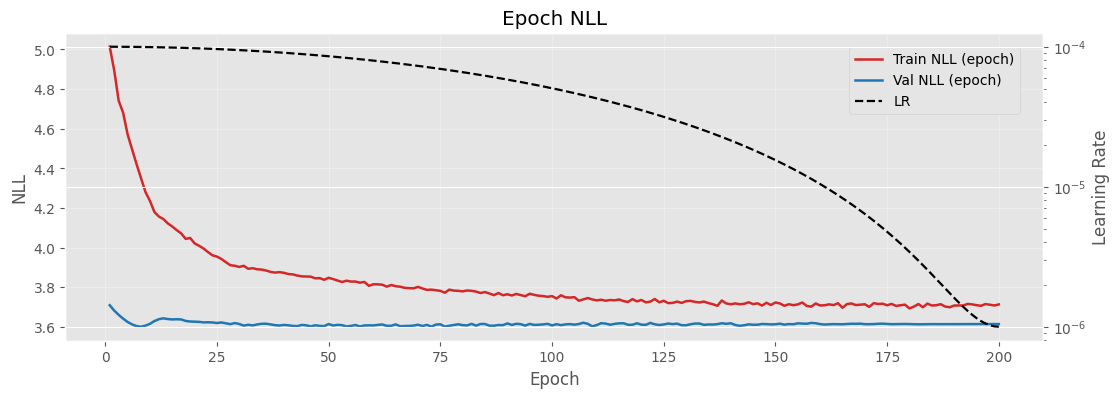

In [33]:
plot_loss(hist)

In [34]:
sigma

^GSPC      0.011287
BTC-USD    0.041952
GC=F       0.009219
cross_1    0.000469
cross_2    0.001275
cross_3    0.000226
cross_4    0.006818
cross_5    0.000533
cross_6    0.000211
dtype: float64

In [35]:
def predict_sigma(model, loader, device='cpu'):
    model.eval()
    sigmas = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            sigma_pred, _ = model(xb)
            sigmas.append(sigma_pred.cpu().numpy())
            targets.append(yb.numpy())

    return np.concatenate(sigmas, axis=0), np.concatenate(targets, axis=0)


sigma_val_scaled, y_val_scaled = predict_sigma(cov_model, vol_val_loader, device=device)
sigma_test_scaled, y_test_scaled = predict_sigma(cov_model, vol_test_loader, device=device)

# Transform covariance back to original return scale:
# if z = (r - mu)/std, then Cov(r) = D Cov(z) D with D = diag(std)

def scale_back(sigma_scaled, sigma=None, feature_cols=None):
    if sigma is not None and feature_cols is not None:
        std_vec = sigma[feature_cols].values.astype(np.float32)
        return sigma_scaled * std_vec[None, :, None] * std_vec[None, None, :]
    else:
        return sigma_scaled

sigma_val_real = scale_back(sigma_val_scaled, sigma=sigma, feature_cols=feature_cols)
sigma_test_real = scale_back(sigma_test_scaled, sigma=sigma, feature_cols=feature_cols)

print('sigma_val_scaled:', sigma_val_scaled.shape)
print('sigma_test_scaled:', sigma_test_scaled.shape)
print('sigma_test_real:', sigma_test_real.shape)
print('sigma_val_real:', sigma_val_real.shape)


sigma_val_scaled: (279, 3, 3)
sigma_test_scaled: (279, 3, 3)
sigma_test_real: (279, 3, 3)
sigma_val_real: (279, 3, 3)


In [36]:
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False) # ohne Shuffle, für Plots

In [37]:
sigma_train_scaled, y_train_scaled = predict_sigma(cov_model, vol_train_eval_loader, device=device)
sigma_train_real = scale_back(sigma_train_scaled, sigma=sigma, feature_cols=feature_cols)

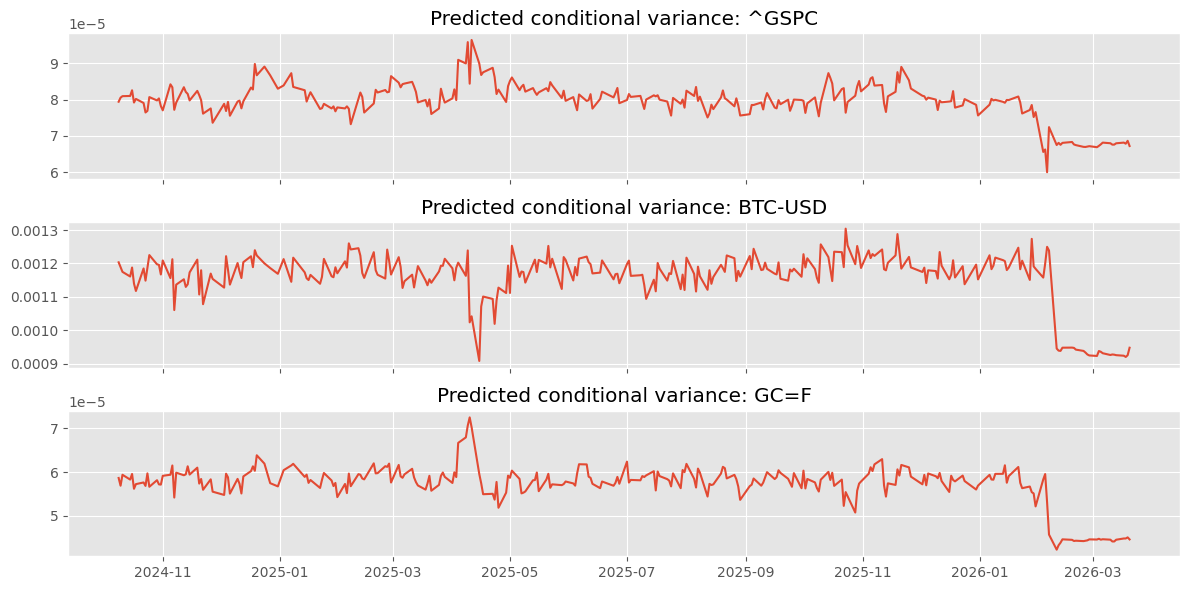

In [38]:
# Quick diagnostic plot: predicted conditional variances
# Build a time index + diagonal variance frame first
test_index_vol = test_df.index[lookback:]
sigma_test_diag_df = pd.DataFrame(
    {
        f'Var({feature_cols[i]})': sigma_test_real[:, i, i]
        for i in range(len(feature_cols))
    },
    index=test_index_vol,
)

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(12, 6), sharex=True)
if len(feature_cols) == 1:
    axes = [axes]

for i, col in enumerate(feature_cols):
    axes[i].plot(sigma_test_diag_df.index, sigma_test_diag_df[f'Var({col})'])
    axes[i].set_title(f'Predicted conditional variance: {col}')

plt.tight_layout()
plt.show()


In [39]:
from statistics import NormalDist
from scipy.stats import t

In [40]:
def plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Test-Split", df=test_df, pred_vol=sigma_test_real, portfolio=False, portfolio_df=None, loss_fn=gaussian_nll, loss_kwargs=None):

    if loss_fn == gaussian_nll:
        z_lo = NormalDist().inv_cdf(alpha)        # z_{alpha}, z.B. -2.326
        z_hi = NormalDist().inv_cdf(1.0 - alpha)  # z_{1-alpha}, z.B. +2.326
    elif loss_fn == student_nll:
        nu = loss_kwargs.get("nu")
        z_lo = t.ppf(alpha, df=nu)
        z_hi = t.ppf(1-alpha, df=nu)

        # muss die Varianz hier noch mit einem Faktor (nu/(nu-2)) skaliert werden, 
        # damit sie mit der Gaussian Varianz vergleichbar ist?

    index_vol = df.index[lookback:]
    rets = df.loc[index_vol, cols].copy()
    
    if portfolio:
        if portfolio_df is None:
            raise ValueError("Bei portfolio=True bitte portfolio_df übergeben.")
        
        idx = portfolio_df.index
        r = portfolio_df["r_p"].values
        vol = portfolio_df["vol_p"].values

        var_lo = z_lo * vol
        var_hi = z_hi * vol

        plt.figure(figsize=(12, 4))
        plt.plot(idx, r, color="black", lw=0.8, label="Portfolio Return", alpha=0.8) 
        plt.plot(idx, var_lo, "--", color="tab:red", lw=1.2, label=f"{alpha:.1%} VaR (lower)")
        plt.plot(idx, var_hi, "--", color="tab:green", lw=1.2, label=f"{1-alpha:.1%} Quantile (upper)")
        plt.fill_between(idx, var_lo, var_hi, alpha=0.12, color="gray")
        plt.title(f"Portfolio: VaR-Bänder ({view})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        hit_rate = np.mean(r < var_lo)
        print(f"Portfolio hit rate = {hit_rate:.3%} (target {alpha:.3%})")
        return

    for i, col in enumerate(cols):
        # sigma_{t+1} aus deiner vorhergesagten Kovarianz Matrix für die Asset i extrahieren
        sigma_t = np.sqrt(np.clip(pred_vol[:, i, i], 1e-12, None))

        var_lo = z_lo * sigma_t   # downside VaR-Linie
        var_hi = z_hi * sigma_t   # obere symmetrische Linie

        r = rets[col].values
        idx = rets.index

        plt.style.use("ggplot")
        plt.figure(figsize=(12, 4))
        plt.plot(idx, r, color="black", lw=0.8, label="Return", alpha=0.7)
        plt.plot(idx, var_lo, "--", color="tab:red", lw=1.2, label=f"{alpha:.1%} VaR (lower)")
        plt.plot(idx, var_hi, "--", color="tab:green", lw=1.2, label=f"{1-alpha:.1%} quantile (upper)")
        plt.fill_between(idx, var_lo, var_hi, alpha=0.12, color="gray")
        plt.title(f"{col}: VaR-Bänder ({view})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Backtest: Anteil der Unterschreitungen sollte ~ alpha sein
        hit_rate = np.mean(r < var_lo)
        print(f"{col}: hit rate = {hit_rate:.3%} (target {alpha:.3%})")


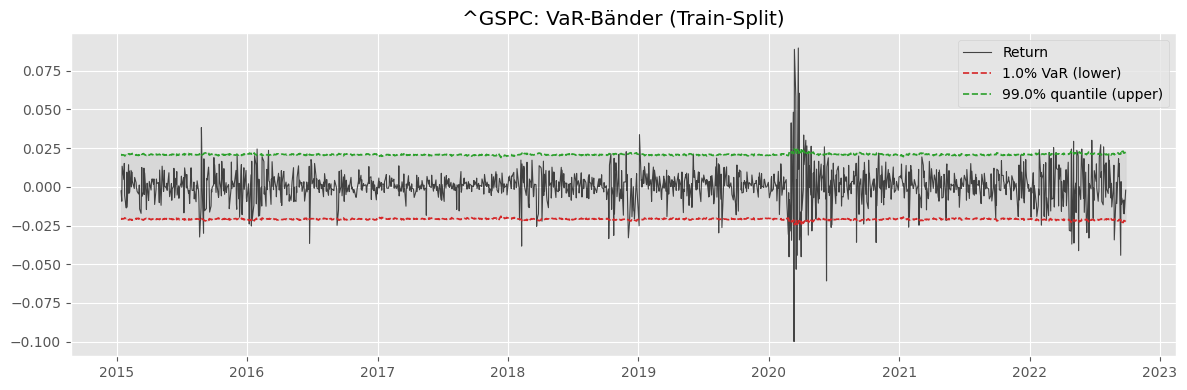

^GSPC: hit rate = 3.485% (target 1.000%)


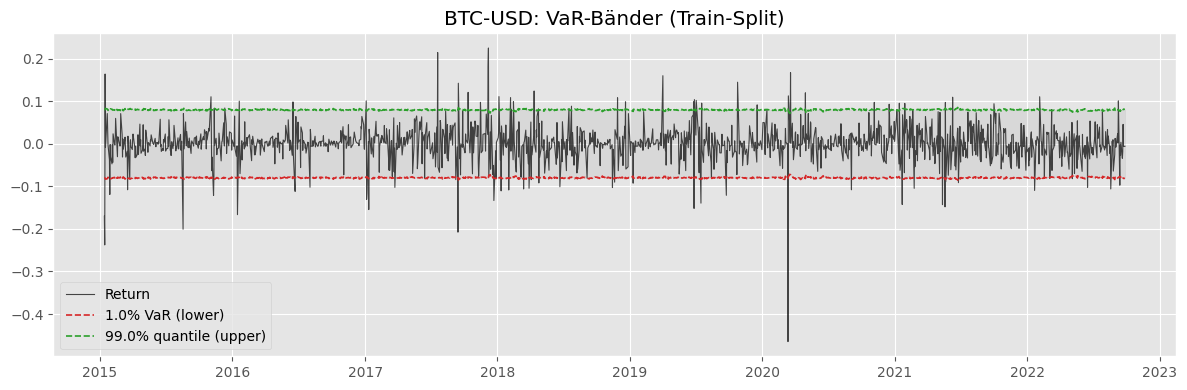

BTC-USD: hit rate = 3.222% (target 1.000%)


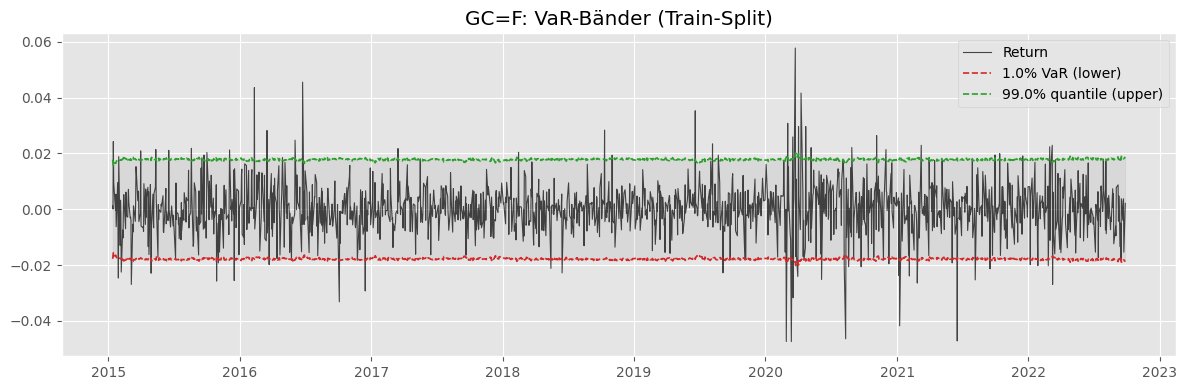

GC=F: hit rate = 2.827% (target 1.000%)


In [41]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Train-Split", df=train_df, pred_vol=sigma_train_real)

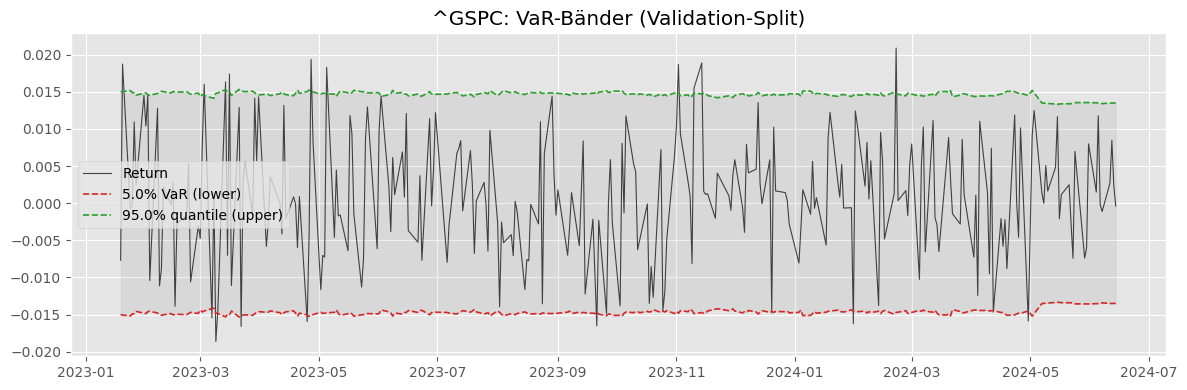

^GSPC: hit rate = 3.226% (target 5.000%)


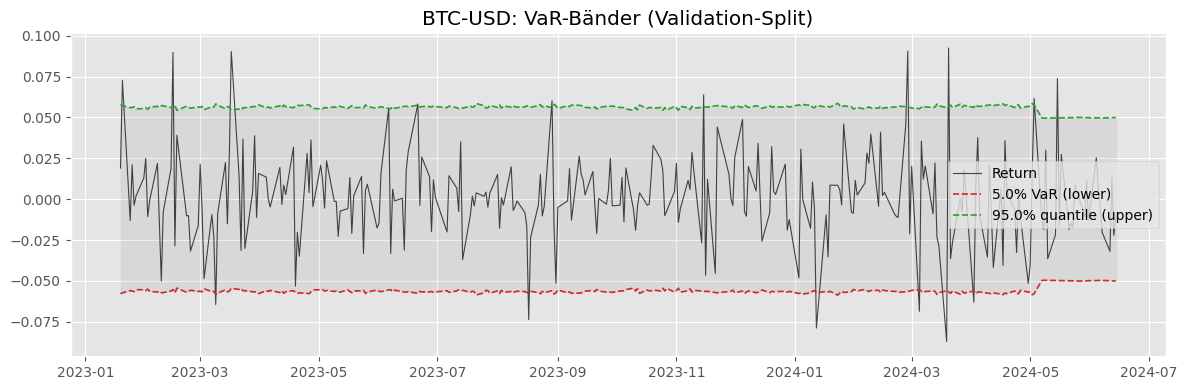

BTC-USD: hit rate = 2.151% (target 5.000%)


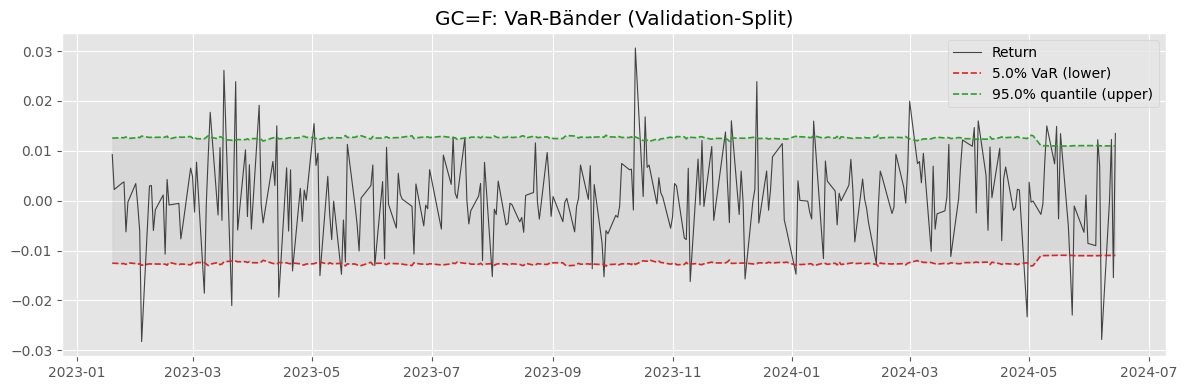

GC=F: hit rate = 6.810% (target 5.000%)


In [42]:
plot_var(alpha=0.05, lookback=lookback, cols=feature_cols, view="Validation-Split", df=val_df, pred_vol=sigma_val_real)

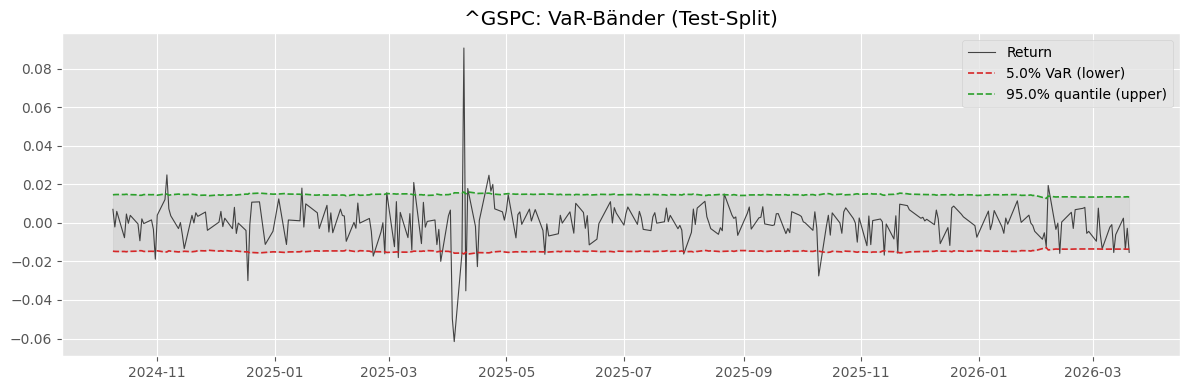

^GSPC: hit rate = 7.168% (target 5.000%)


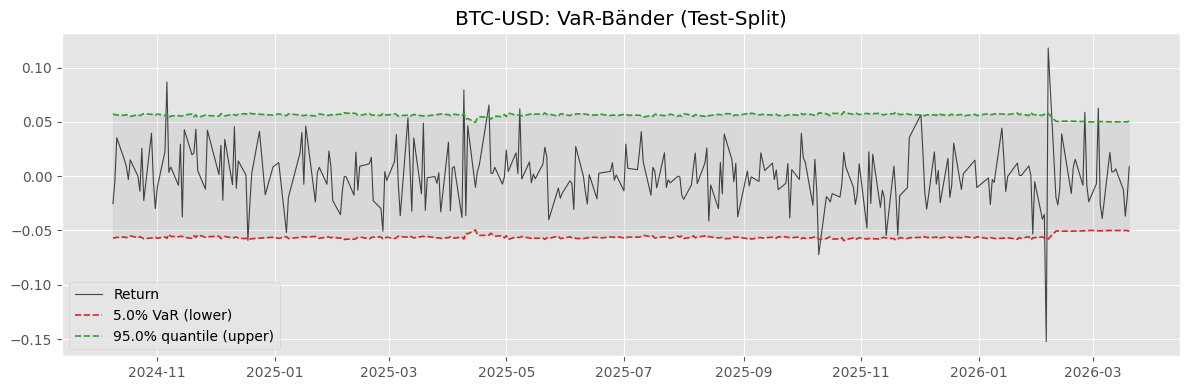

BTC-USD: hit rate = 1.075% (target 5.000%)


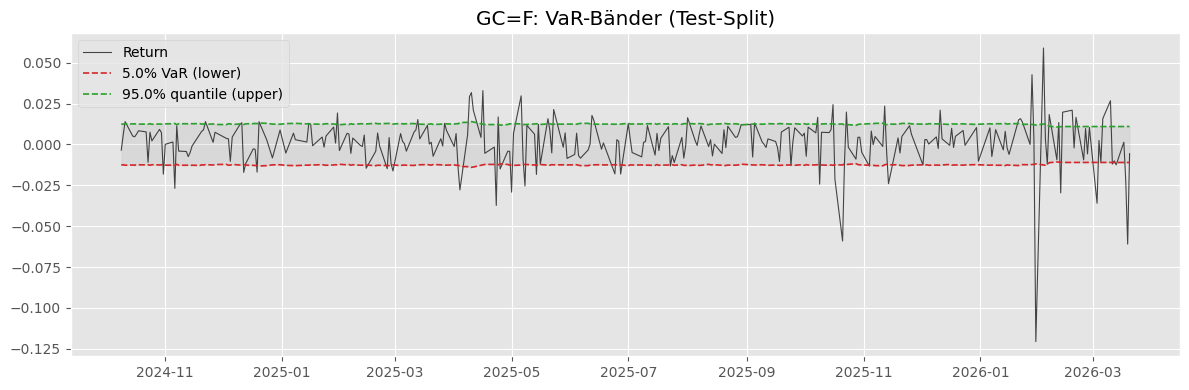

GC=F: hit rate = 11.470% (target 5.000%)


In [43]:
plot_var(alpha=0.05, lookback=lookback, cols=feature_cols, view="Test-Split", df=test_df, pred_vol=sigma_test_real)

In [44]:
train_df.shape, val_df.shape, test_df.shape

((1581, 9), (339, 9), (339, 9))

# Portfolio Berechnungen

Portfolio Weights & Portfolio Return $r_{p,t} = w^\top \cdot r_t$

$w = (w_1, w_2, \dots, w_n)^\top$ mit $\sum_i^n w_i = 1$

Portfolio Variance:

$\sigma^2_{p,t} = w^\top \Sigma_t w$


In [45]:
w = torch.tensor([0.5, 0.4, 0.1])

In [46]:
w.shape

torch.Size([3])

In [47]:
logret.shape

(2259, 3)

In [48]:
torch.tensor(logret.values).shape

torch.Size([2259, 3])

In [49]:
portfolio_logrets = (w * torch.tensor(logret.values)).sum(dim=1)

In [50]:
portfolio_logrets.shape

torch.Size([2259])

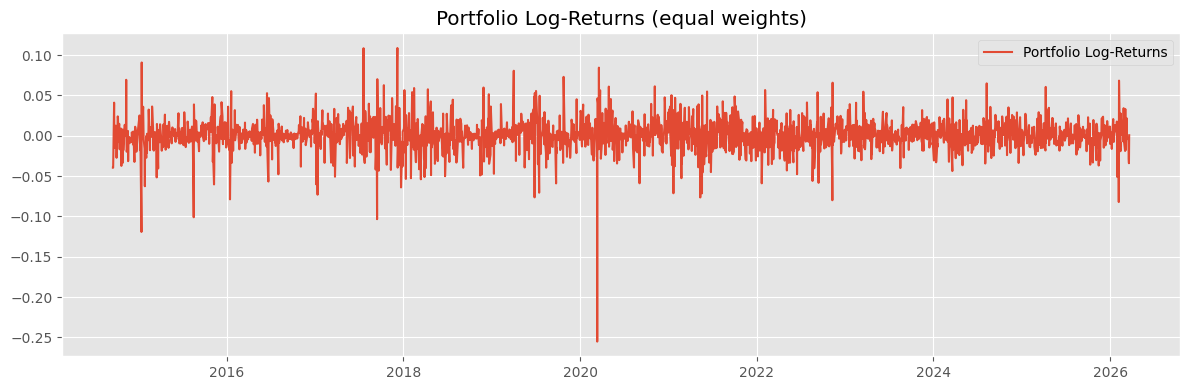

In [51]:
plt.figure(figsize=(12, 4))
plt.plot(logret.index, portfolio_logrets, label="Portfolio Log-Returns")
plt.title("Portfolio Log-Returns (equal weights)")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
w = np.array([0.5, 0.4, 0.1], dtype=np.float32)
w

array([0.5, 0.4, 0.1], dtype=float32)

In [53]:
def calc_portfolio_variance(df_split, sigma_split, cols, lookback, w):
    idx = df_split.index[lookback:]
    r = df_split.loc[idx, cols].values  # (N-lookback, d)
    r_p = (w*r).sum(axis=1)  # (N-lookback,) Portfolio-Logreturns
    tmp = sigma_split @ w          # (T, d)  = Σ_t w
    var_p = (w * tmp).sum(axis=1) # (1,) = w^T (Σ_t w) Portfolio-Varianz pro t
    vol_p = np.sqrt(var_p)
    
    return idx, r_p, var_p, vol_p

## LSTM mit Normal Loss

In [54]:
idx_test, rp_test, varp_test, volp_test = calc_portfolio_variance(
    test_df, sigma_test_real, feature_cols, lookback, w
)

idx_val, rp_val, varp_val, volp_val = calc_portfolio_variance(
    val_df, sigma_val_real, feature_cols, lookback, w
)

idx_train, rp_train, varp_train, volp_train = calc_portfolio_variance(
    train_df, sigma_train_real, feature_cols, lookback, w
)

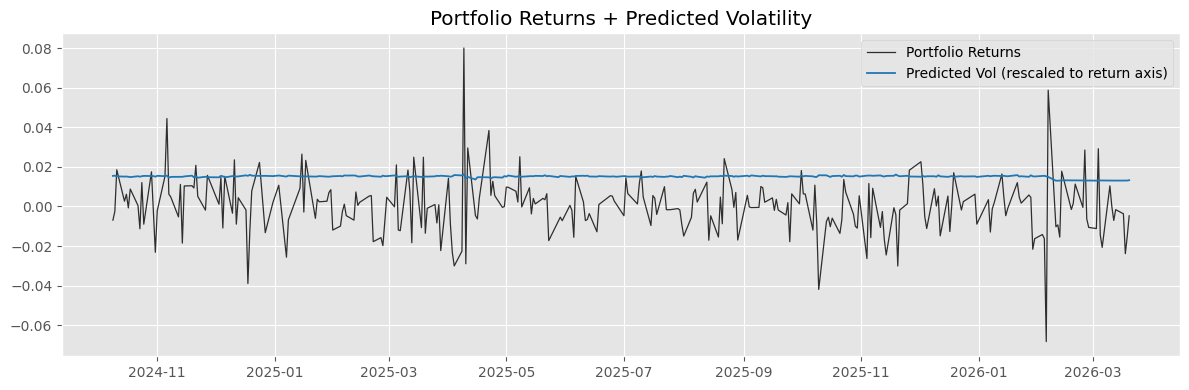

In [55]:
r = np.asarray(rp_test, dtype=float)
v = np.asarray(volp_test, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
def make_portfolio_df(idx, rp, varp, volp):
    return pd.DataFrame(
        {
            "r_p": np.asarray(rp, dtype=float),
            "var_p": np.asarray(varp, dtype=float),
            "vol_p": np.asarray(volp, dtype=float),
        },
        index=idx,
    )

In [57]:
portfolio_test = make_portfolio_df(idx_test, rp_test, varp_test, volp_test)
portfolio_val = make_portfolio_df(idx_val, rp_val, varp_val, volp_val)
portfolio_train = make_portfolio_df(idx_train, rp_train, varp_train, volp_train)

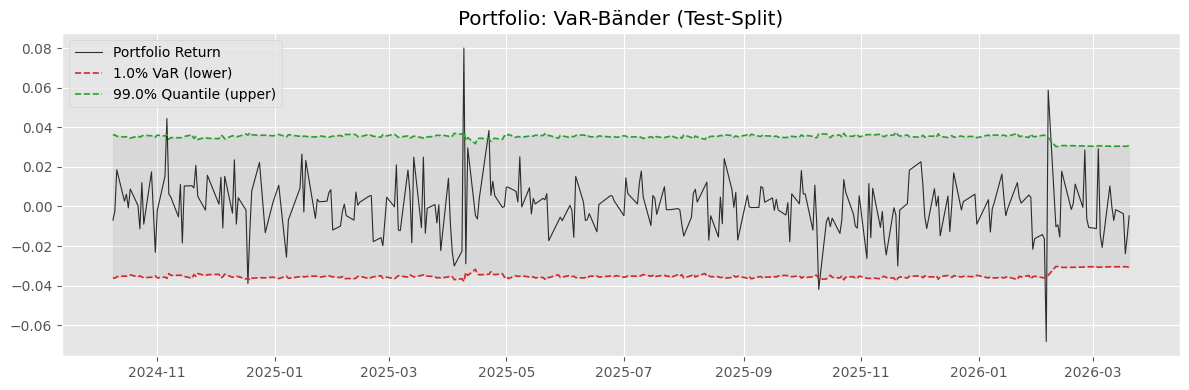

Portfolio hit rate = 1.075% (target 1.000%)


In [58]:
plot_var(alpha=0.01, lookback=lookback, view="Test-Split", portfolio=True, portfolio_df=portfolio_test)

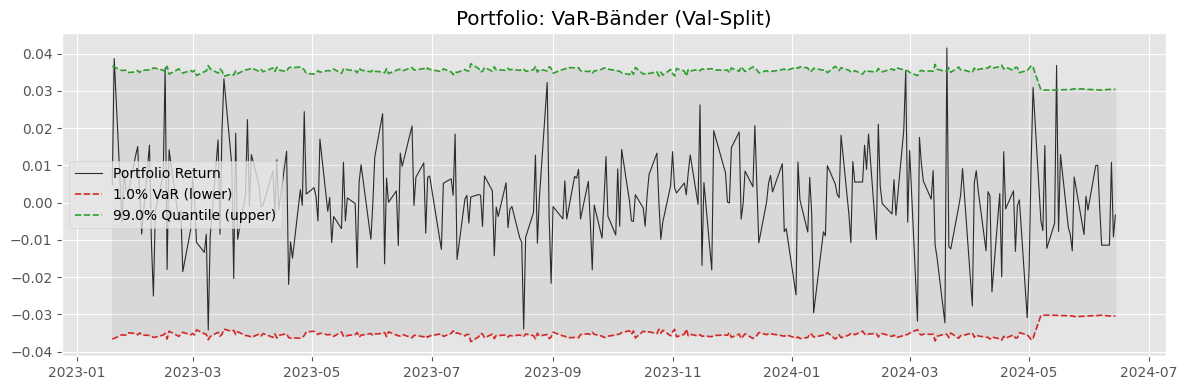

Portfolio hit rate = 0.000% (target 1.000%)


In [59]:
plot_var(alpha=0.01, lookback=lookback, view="Val-Split", portfolio=True, portfolio_df=portfolio_val)

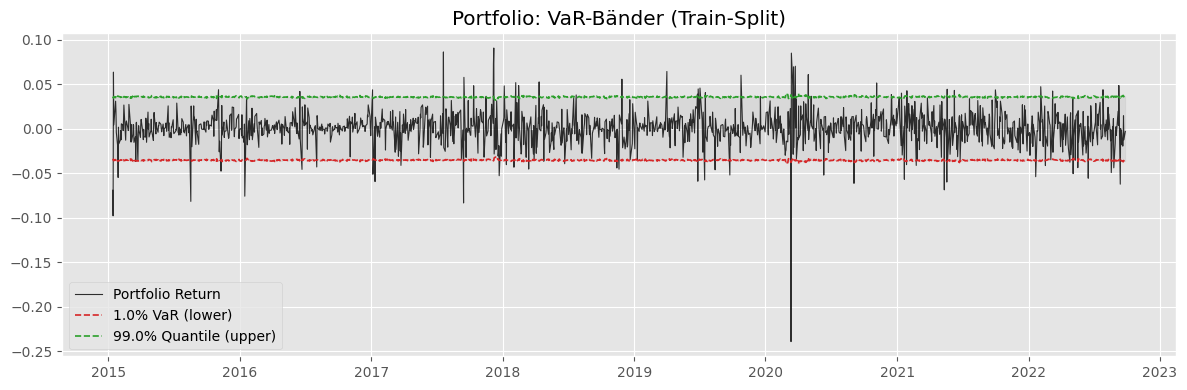

Portfolio hit rate = 3.156% (target 1.000%)


In [60]:
plot_var(alpha=0.01, lookback=lookback, view="Train-Split", portfolio=True, portfolio_df=portfolio_train)

## LSTM mit Student-t Loss

Modell mit Studen-t-Verteilung

In [61]:
loss_kwargs = {"nu": 5.0}  # vieleicht mit trainieren?

In [62]:
k = len(feature_cols)*(len(feature_cols)+1)//2 # Anzahl an Cross Returns, die zusätzlich zu den normalen Returns als Input-Features für die Kovarianzmodellierung genutzt werden

cov_model_t = LSTMCovariance(input_size=(len(feature_cols)+k), n_assets=len(feature_cols), hidden_size=64, num_layers=2, dropout=0.2)
cov_model_t, hist_t = train_covariance_model(
    cov_model_t,
    vol_train_loader,
    vol_val_loader,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    epochs=500,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="cosine",  # oder "cosine"
)

Epoch 001 | train NLL 3.945915 | val NLL 3.577439 | lr 1.00e-04
Epoch 002 | train NLL 3.929941 | val NLL 3.568351 | lr 1.00e-04
Epoch 003 | train NLL 3.915850 | val NLL 3.561104 | lr 1.00e-04
Epoch 004 | train NLL 3.910850 | val NLL 3.553688 | lr 1.00e-04
Epoch 005 | train NLL 3.901289 | val NLL 3.548320 | lr 1.00e-04
Epoch 006 | train NLL 3.895701 | val NLL 3.542006 | lr 1.00e-04
Epoch 007 | train NLL 3.890653 | val NLL 3.538312 | lr 1.00e-04
Epoch 008 | train NLL 3.885975 | val NLL 3.532880 | lr 9.99e-05
Epoch 009 | train NLL 3.875603 | val NLL 3.529887 | lr 9.99e-05
Epoch 010 | train NLL 3.873465 | val NLL 3.527512 | lr 9.99e-05
Epoch 011 | train NLL 3.865541 | val NLL 3.524993 | lr 9.99e-05
Epoch 012 | train NLL 3.859009 | val NLL 3.522725 | lr 9.99e-05
Epoch 013 | train NLL 3.853307 | val NLL 3.519968 | lr 9.98e-05
Epoch 014 | train NLL 3.849897 | val NLL 3.518236 | lr 9.98e-05
Epoch 015 | train NLL 3.838216 | val NLL 3.516146 | lr 9.98e-05
Epoch 016 | train NLL 3.830897 | val NLL

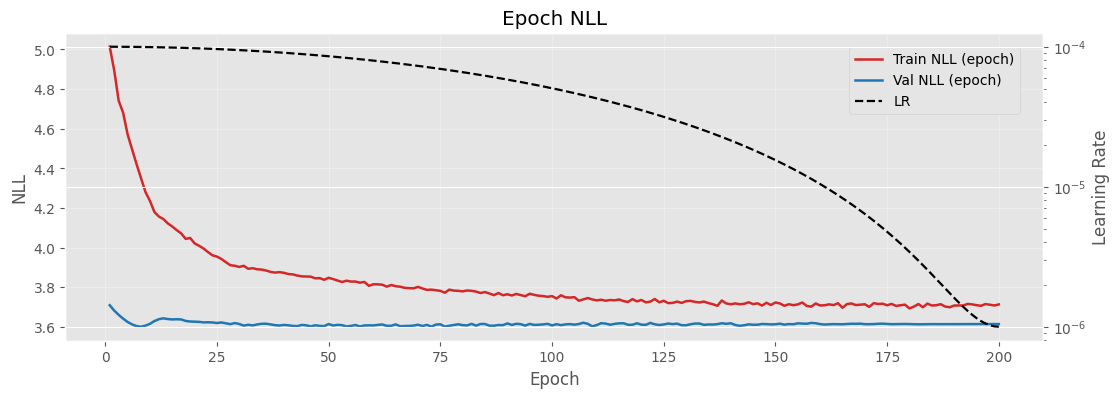

In [63]:
plot_loss(hist)

In [64]:
sigma_val_scaled_t, y_val_scale_t = predict_sigma(cov_model_t, vol_val_loader, device=device)
sigma_test_scaled_t, y_test_scaled_t = predict_sigma(cov_model_t, vol_test_loader, device=device)

sigma_val_real_t = scale_back(sigma_val_scaled_t, sigma=sigma, feature_cols=feature_cols)
sigma_test_real_t = scale_back(sigma_test_scaled_t, sigma=sigma, feature_cols=feature_cols)

In [65]:
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False)
sigma_train_scaled_t, y_train_scaled_t = predict_sigma(cov_model_t, vol_train_eval_loader, device=device)
sigma_train_real_t = scale_back(sigma_train_scaled_t, sigma=sigma, feature_cols=feature_cols)

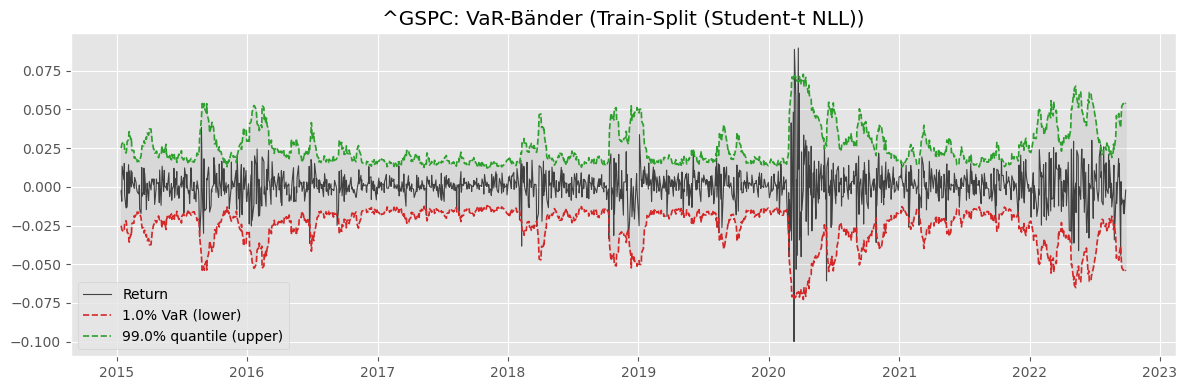

^GSPC: hit rate = 1.644% (target 1.000%)


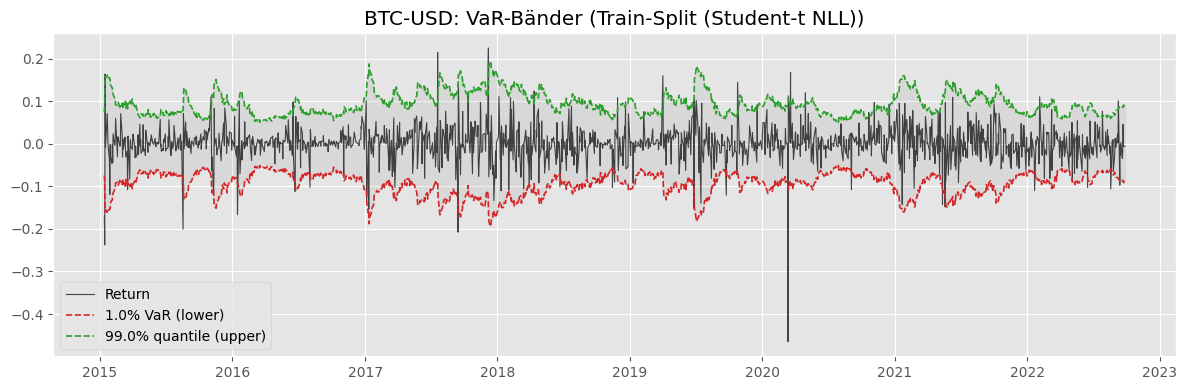

BTC-USD: hit rate = 1.775% (target 1.000%)


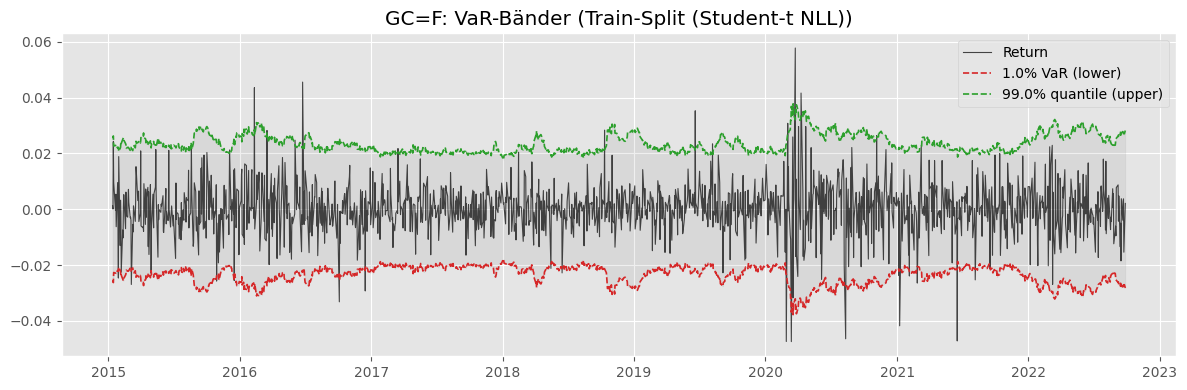

GC=F: hit rate = 1.315% (target 1.000%)


In [66]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Train-Split (Student-t NLL)", df=train_df, pred_vol=sigma_train_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

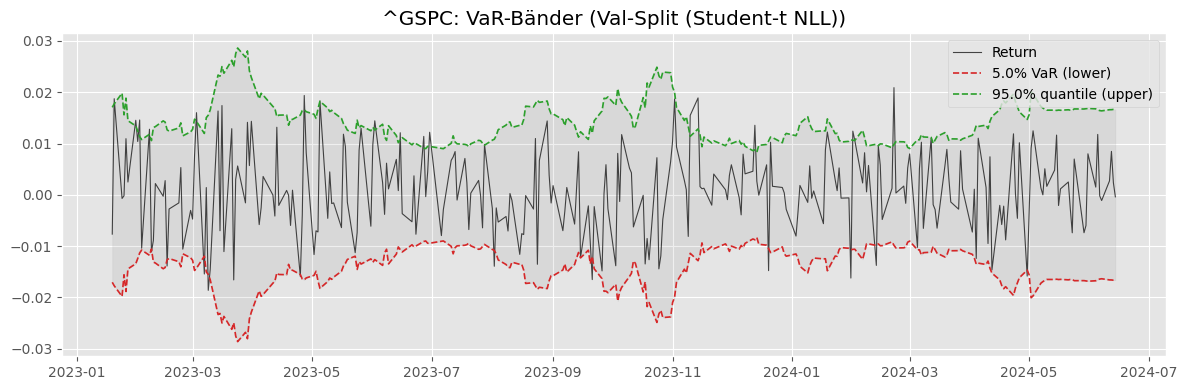

^GSPC: hit rate = 3.943% (target 5.000%)


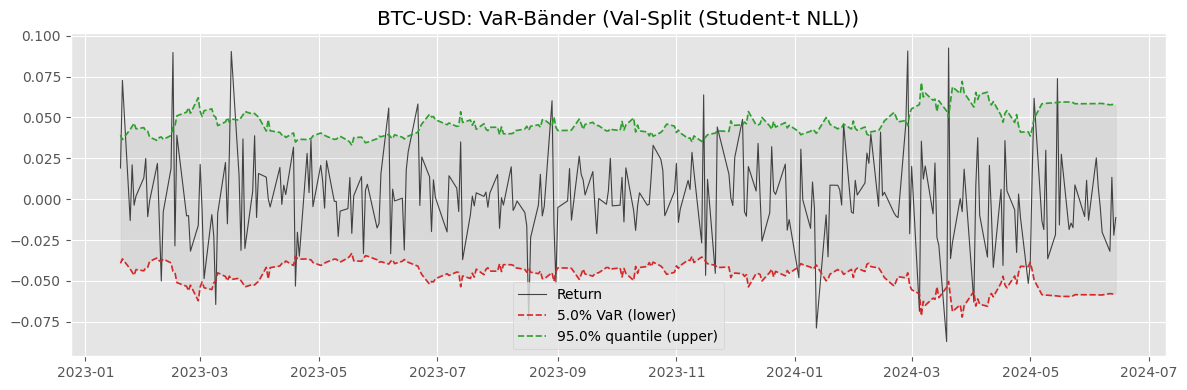

BTC-USD: hit rate = 5.018% (target 5.000%)


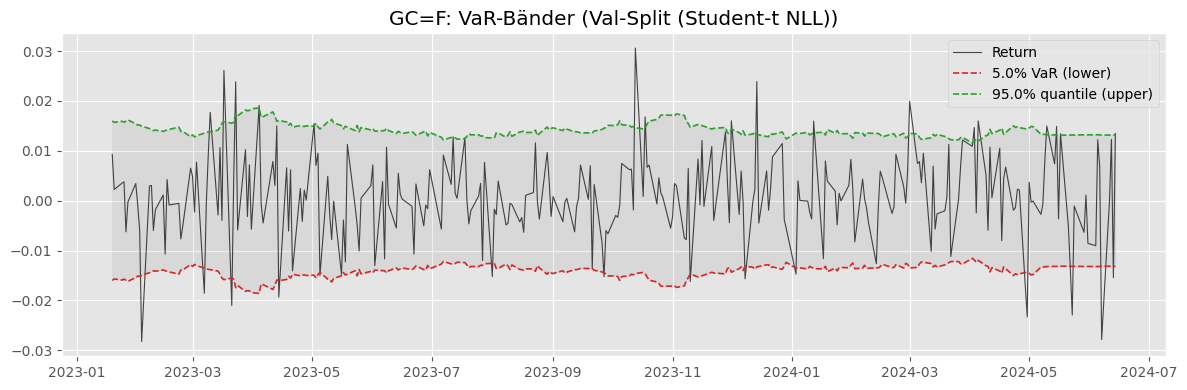

GC=F: hit rate = 5.735% (target 5.000%)


In [67]:
plot_var(alpha=0.05, lookback=lookback, cols=feature_cols, view="Val-Split (Student-t NLL)", df=val_df, pred_vol=sigma_val_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

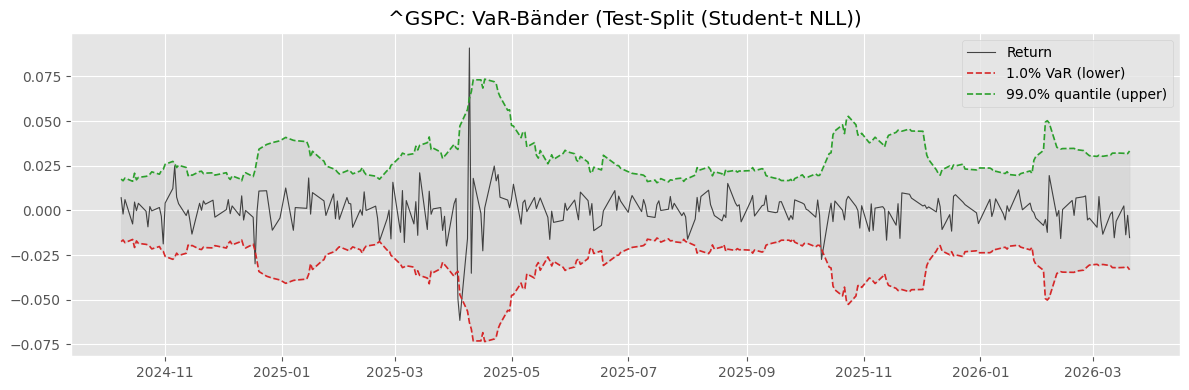

^GSPC: hit rate = 1.434% (target 1.000%)


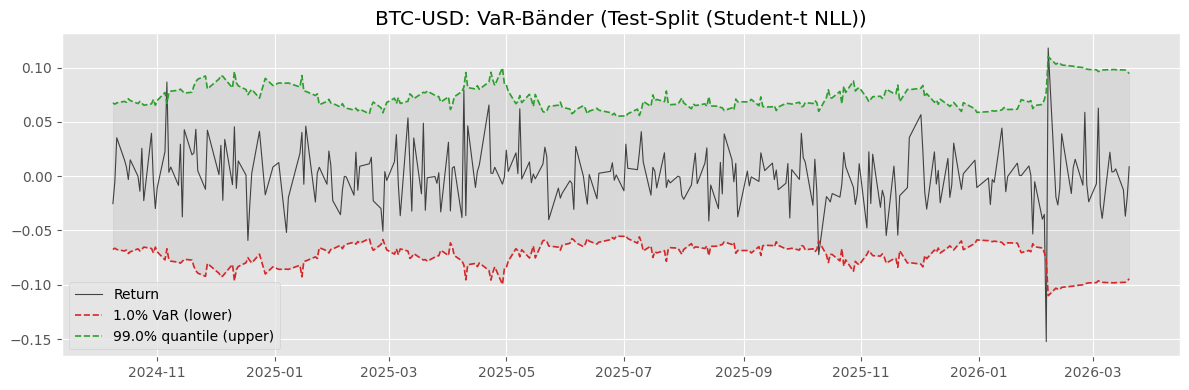

BTC-USD: hit rate = 0.717% (target 1.000%)


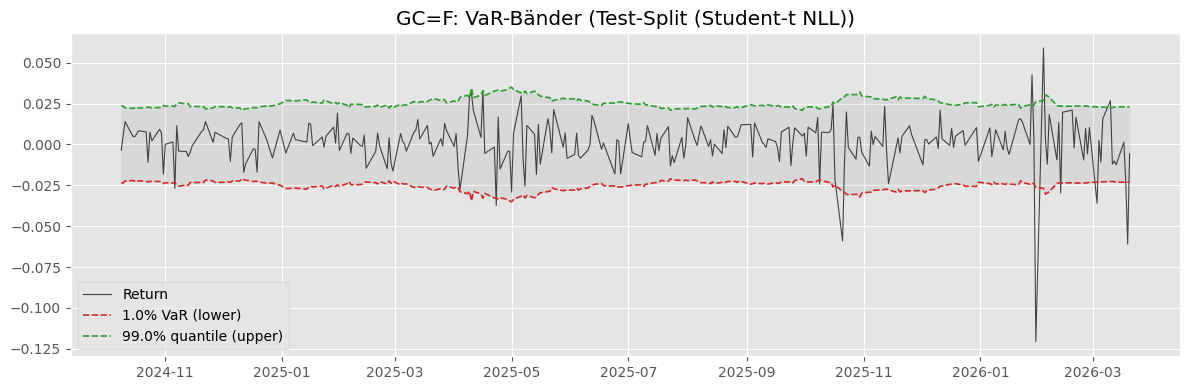

GC=F: hit rate = 2.867% (target 1.000%)


In [68]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Test-Split (Student-t NLL)", df=test_df, pred_vol=sigma_test_real_t, loss_fn=student_nll, loss_kwargs=loss_kwargs)

- Hier müssten jetzt noch mal die Portfolio Returns & Volas mit ```make_portfolio_df``` berechnet werden für Student-t Verteilung!

In [69]:
idx_test_t, rp_test_t, varp_test_t, volp_test_t = calc_portfolio_variance(
    test_df, sigma_test_real_t, feature_cols, lookback, w
)

idx_val_t, rp_val_t, varp_val_t, volp_val_t = calc_portfolio_variance(
    val_df, sigma_val_real_t, feature_cols, lookback, w
)

idx_train_t, rp_train_t, varp_train_t, volp_train_t = calc_portfolio_variance(
    train_df, sigma_train_real_t, feature_cols, lookback, w
)

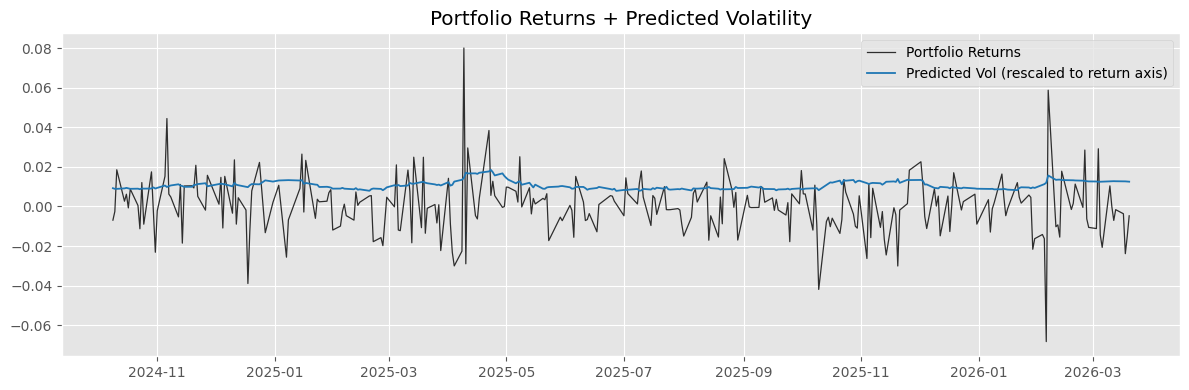

In [70]:
r = np.asarray(rp_test_t, dtype=float)
v = np.asarray(volp_test_t, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
portfolio_test_t = make_portfolio_df(idx_test_t, rp_test_t, varp_test_t, volp_test_t)
portfolio_val_t = make_portfolio_df(idx_val_t, rp_val_t, varp_val_t, volp_val_t)
portfolio_train_t = make_portfolio_df(idx_train_t, rp_train_t, varp_train_t, volp_train_t)

Modell mit skewed Studen-t-Verteilung

## Filtered Historical Simulation

- bisher FHS nur mit Normal Volas

In [72]:
from risk_metrics import fhs_var_es

In [124]:
alpha = 0.05
window = 500  # z.B. 250/500/1000 testen

### Normal Loss (Portfolio)

In [125]:
z_train = portfolio_train["r_p"].values / np.clip(portfolio_train["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val = portfolio_val["r_p"].values / np.clip(portfolio_val["vol_p"].values, 1e-12, None)
z_test = portfolio_test["r_p"].values / np.clip(portfolio_test["vol_p"].values, 1e-12, None)
z_train_val =np.concatenate([z_train, z_val])


var_fhs_test, es_fhs_test, hits_test = fhs_var_es(
    z_hist_init=z_train_val, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test["r_p"].values,
    vol_oos=portfolio_test["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test = hits_test.mean()
print(f"FHS Test hit rate = {hit_rate_test:.3%} (target {alpha:.3%})")

FHS Test hit rate = 3.943% (target 5.000%)


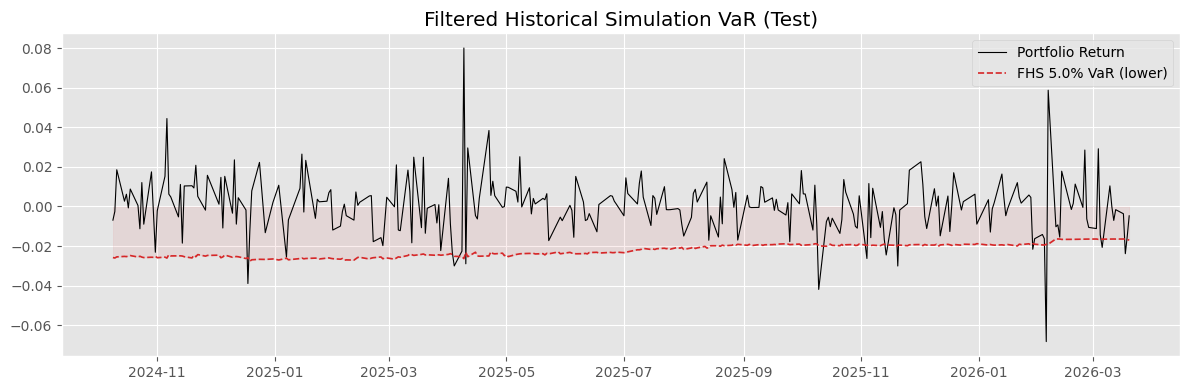

In [126]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_test.index, portfolio_test["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_test.index, var_fhs_test, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_test.index, var_fhs_test, np.zeros_like(var_fhs_test), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Test)")
plt.legend()
plt.tight_layout()
plt.show()

- Falls FHS auf train genutzt werden soll, muss zuvor ein z_train_burn_in genutzt werden wo zb die ersten 500 z_t aus train genutzt werden für die historie und von dort aus wird dann der VaR rollierend berechnet!

In [76]:
z_train_burn_in = z_train[:window]

In [77]:
var_fhs_train, es_fhs_train, hit_train = fhs_var_es(
    z_hist_init=z_train_burn_in, # custom burn-in für Historie nötig
    r_oos=portfolio_train["r_p"][window:].values,
    vol_oos=portfolio_train["vol_p"][window:].values,
    alpha=alpha,
    window=window
)

hit_rate_train = hit_train.mean()
print(f"FHS Train hit rate = {hit_rate_train:.3%} (target {alpha:.3%})")

FHS Train hit rate = 1.567% (target 1.000%)


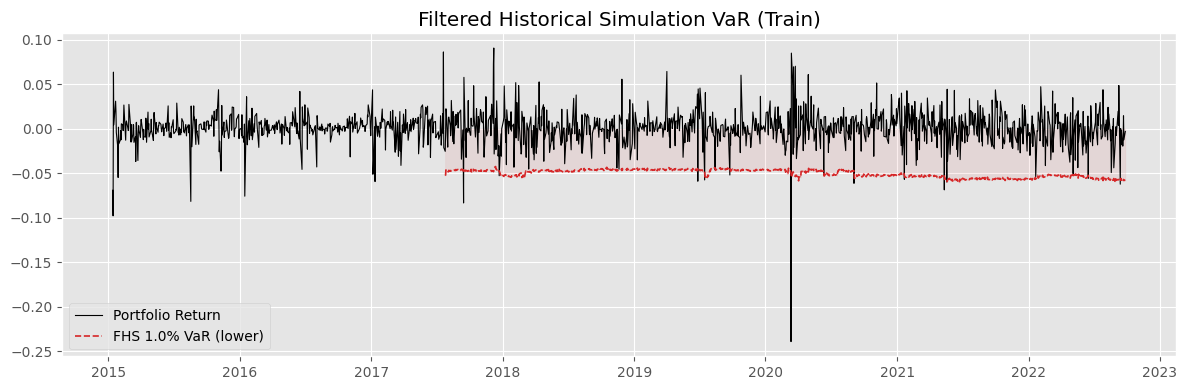

In [78]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_train.index, portfolio_train["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_train[window:].index, var_fhs_train, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_train[window:].index, var_fhs_train, np.zeros_like(var_fhs_train), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Train)")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
var_fhs_val, es_fhs_val, hit_val = fhs_var_es(
    z_hist_init=z_train,
    r_oos=portfolio_val["r_p"].values,
    vol_oos=portfolio_val["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_val = hit_val.mean()
print(f"FHS Val hit rate = {hit_rate_val:.3%} (target {alpha:.3%})")

FHS Val hit rate = 0.000% (target 1.000%)


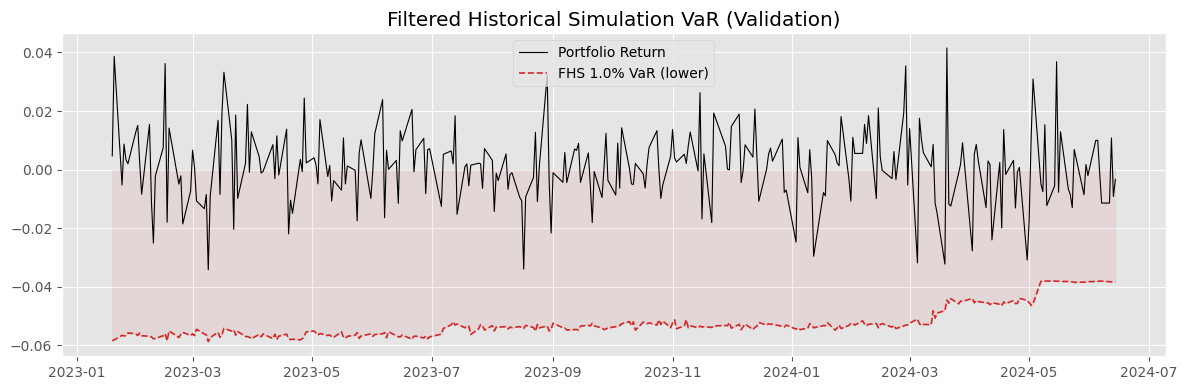

In [80]:
plt.figure(figsize=(12,4))
plt.plot(portfolio_val.index, portfolio_val["r_p"].values, color="black", lw=0.8, label="Portfolio Return")
plt.plot(portfolio_val.index, var_fhs_val, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
plt.fill_between(portfolio_val.index, var_fhs_val, np.zeros_like(var_fhs_val), color="tab:red", alpha=0.08)
plt.title("Filtered Historical Simulation VaR (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

### Student-t Loss (Portfolio)

In [127]:
z_train_t = portfolio_train_t["r_p"].values / np.clip(portfolio_train_t["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val_t = portfolio_val_t["r_p"].values / np.clip(portfolio_val_t["vol_p"].values, 1e-12, None)
z_test_t = portfolio_test_t["r_p"].values / np.clip(portfolio_test_t["vol_p"].values, 1e-12, None)
z_train_val_t =np.concatenate([z_train_t, z_val_t])


var_fhs_test_t, es_fhs_test_t, hits_test_t = fhs_var_es(
    z_hist_init=z_train_val_t, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test_t["r_p"].values,
    vol_oos=portfolio_test_t["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test_t = hits_test_t.mean()
print(f"FHS Test hit rate = {hit_rate_test_t:.3%} (target {alpha:.3%})")

FHS Test hit rate = 3.943% (target 5.000%)


# MGARCH-LSTM mit BEKK Kernel Function (Zhao et al. 2024)

$s_{t-1} := \operatorname{vech}(\Sigma_{t-1})$

$$
f_t = \sigma_g\!\left(W_f \varepsilon_{t-1} 
      + U_f s_{t-1} 
      + b_f\right), \\
i_t = \sigma_g\!\left(W_i \varepsilon_{t-1} 
      + U_i s_{t-1} 
      + b_i\right), \\
\tilde c_t = \sigma_c\!\left(W_c \varepsilon_{t-1} 
      + U_c s_{t-1} 
      + b_c\right), \\
c_t = f_t \odot c_{t-1} 
      + i_t \odot \tilde c_t.
$$

The output gate can then be reinterpreted as a BEKK kernel output
$$
o_t := \mathcal{K}_{\text{BEKK}}(\varepsilon_{t-1}, \Sigma_{t-1}; \Theta), \\
\mathcal{K}_{\text{BEKK}} = C C^\top 
      + A^\top \varepsilon_{t-1}\varepsilon_{t-1}^\top A 
      + B^\top \Sigma_{t-1} B.
$$

$$m_t = 1 + \beta \tanh(w_o^\top \tanh(c_t) + b_o)$$

$$\Sigma_t
= o_t \times m_t = 
\underbrace{m_t}_{\text{LSTM}}
\times
\underbrace{
\left(
CC^\top
+
A^\top \varepsilon_{t-1}\varepsilon_{t-1}^\top A
+
B^\top \Sigma_{t-1} B
\right)
}_{\text{BEKK(1,1)}}$$

In [105]:
from bekk_kernel import BEKKCell, BEKKLSTM

- Es müssen neue Dataset & Dataloader angelegt werden, da die MGARCH Kernel Function ein BEKK(1,1) ist. Daher ist der bisherige ```lookback=60``` nicht passend.

In [106]:
loss_kwargs = {"nu": 10.0}

In [108]:
bekk_kernel_lstm = BEKKLSTM(input_size=(len(feature_cols)+k), n_assets=len(feature_cols), hidden_size=64, asym=True)
bekk_kernel_lstm, hist_bekk = train_covariance_model(
    bekk_kernel_lstm,
    vol_train_loader,
    vol_val_loader,
    loss_fn=student_nll,
    loss_kwargs=loss_kwargs,
    epochs=200,
    lr=1e-4,
    plateau_patience=20,
    device=device,
    scheduler_type="plateau",  # oder "cosine"
)

Epoch 001 | train NLL 4.642244 | val NLL 4.369729 | lr 1.00e-04
Epoch 002 | train NLL 4.504939 | val NLL 4.231108 | lr 1.00e-04
Epoch 003 | train NLL 4.394652 | val NLL 4.118765 | lr 1.00e-04
Epoch 004 | train NLL 4.310324 | val NLL 4.025493 | lr 1.00e-04
Epoch 005 | train NLL 4.235702 | val NLL 3.946787 | lr 1.00e-04
Epoch 006 | train NLL 4.175223 | val NLL 3.879495 | lr 1.00e-04
Epoch 007 | train NLL 4.126232 | val NLL 3.821877 | lr 1.00e-04
Epoch 008 | train NLL 4.084879 | val NLL 3.772014 | lr 1.00e-04
Epoch 009 | train NLL 4.046199 | val NLL 3.728973 | lr 1.00e-04
Epoch 010 | train NLL 4.015211 | val NLL 3.692068 | lr 1.00e-04
Epoch 011 | train NLL 3.992147 | val NLL 3.660358 | lr 1.00e-04
Epoch 012 | train NLL 3.971768 | val NLL 3.633339 | lr 1.00e-04
Epoch 013 | train NLL 3.953578 | val NLL 3.611023 | lr 1.00e-04
Epoch 014 | train NLL 3.944630 | val NLL 3.592806 | lr 1.00e-04
Epoch 015 | train NLL 3.931513 | val NLL 3.579651 | lr 1.00e-04
Epoch 016 | train NLL 3.925182 | val NLL

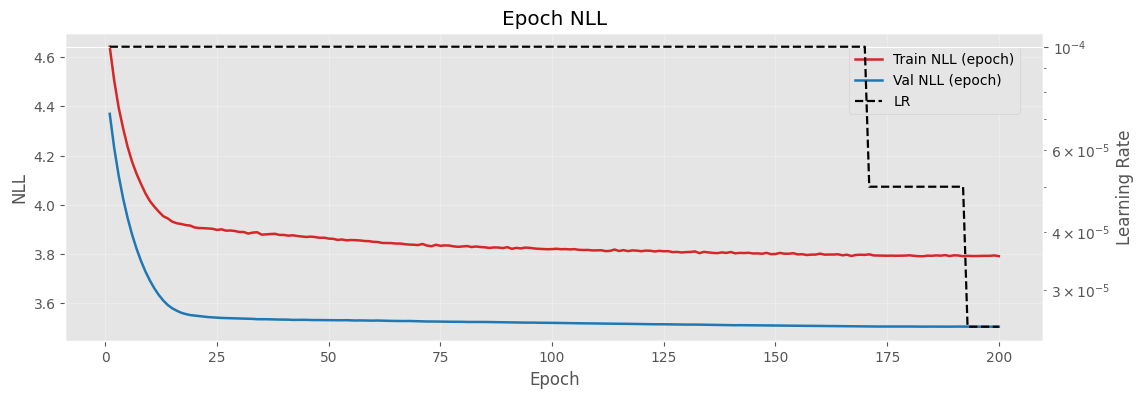

In [109]:
plot_loss(hist_bekk)

In [ ]:
sigma_val_scaled_bekk, y_val_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_val_loader, device=device)
sigma_val_real_bekk = scale_back(sigma_val_scaled_bekk, sigma=sigma, feature_cols=feature_cols)

sigma_test_scaled_bekk, y_test_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_test_loader, device=device)
sigma_test_real_bekk = scale_back(sigma_test_scaled_bekk, sigma=sigma, feature_cols=feature_cols)


sigma_train_scaled_bekk, y_train_scaled_bekk = predict_sigma(bekk_kernel_lstm, vol_train_eval_loader, device=device)
sigma_train_real_bekk = scale_back(sigma_train_scaled_bekk, sigma=sigma, feature_cols=feature_cols)

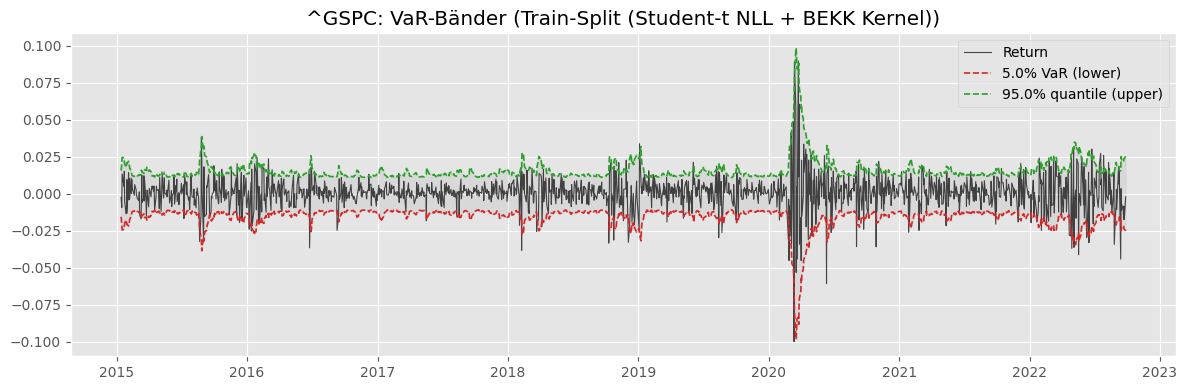

^GSPC: hit rate = 4.865% (target 5.000%)


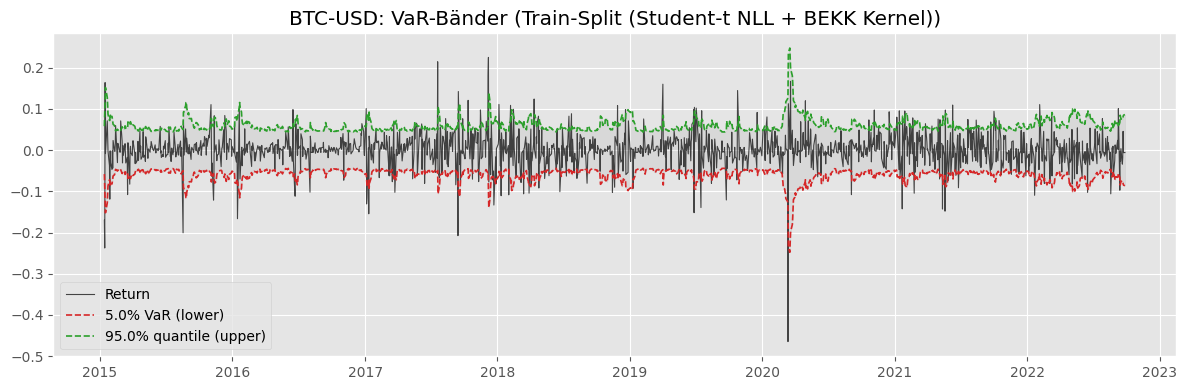

BTC-USD: hit rate = 6.377% (target 5.000%)


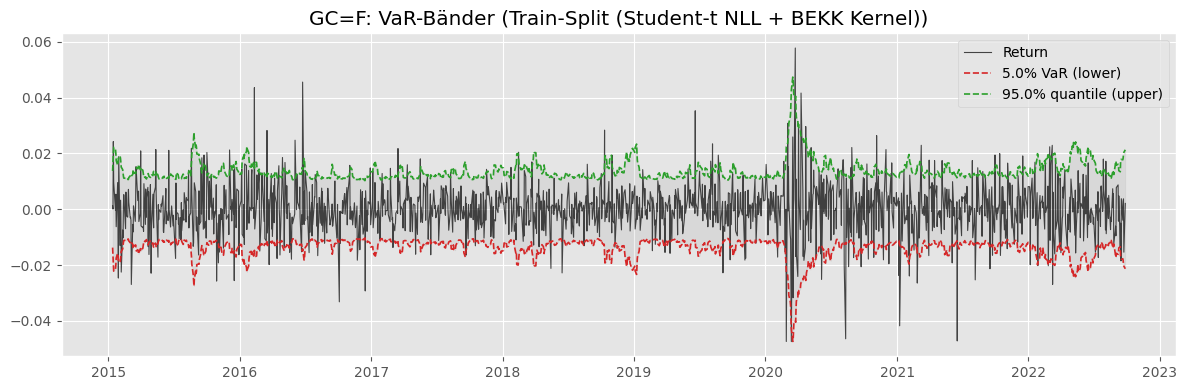

GC=F: hit rate = 5.786% (target 5.000%)


In [111]:
plot_var(alpha=0.05, lookback=lookback, cols=feature_cols, view="Train-Split (Student-t NLL + BEKK Kernel)", df=train_df, pred_vol=sigma_train_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

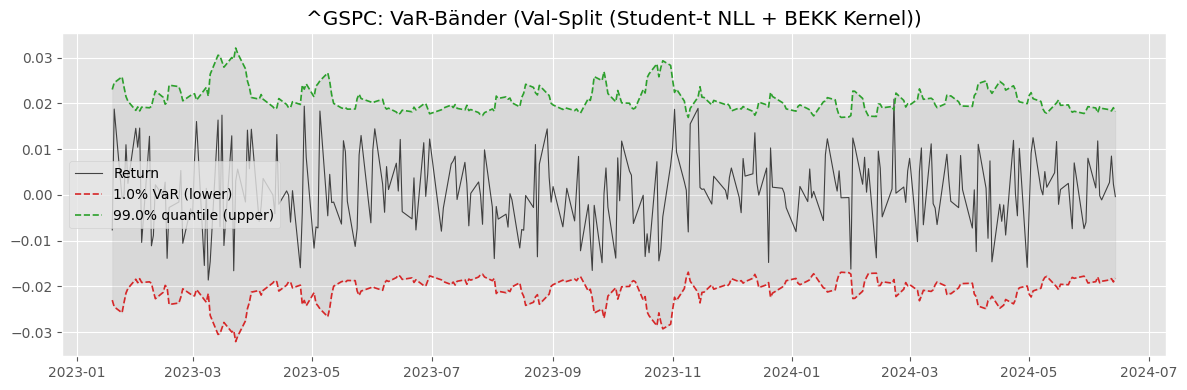

^GSPC: hit rate = 0.000% (target 1.000%)


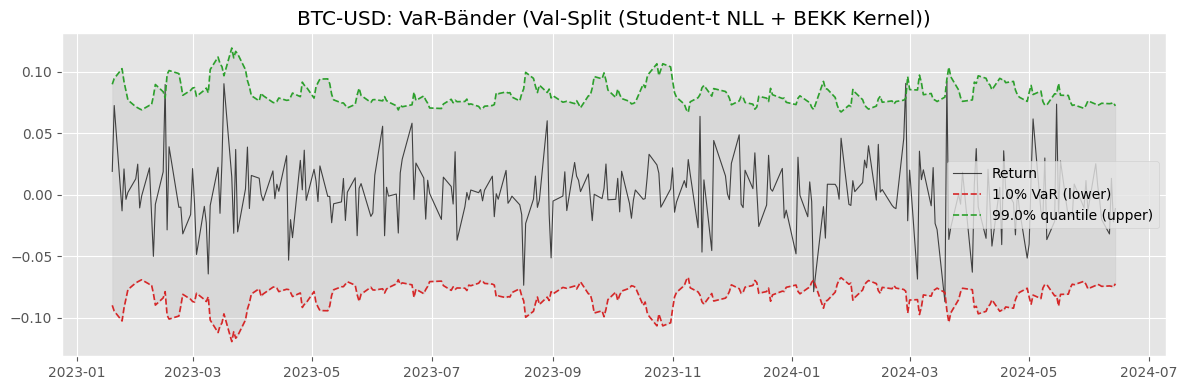

BTC-USD: hit rate = 0.717% (target 1.000%)


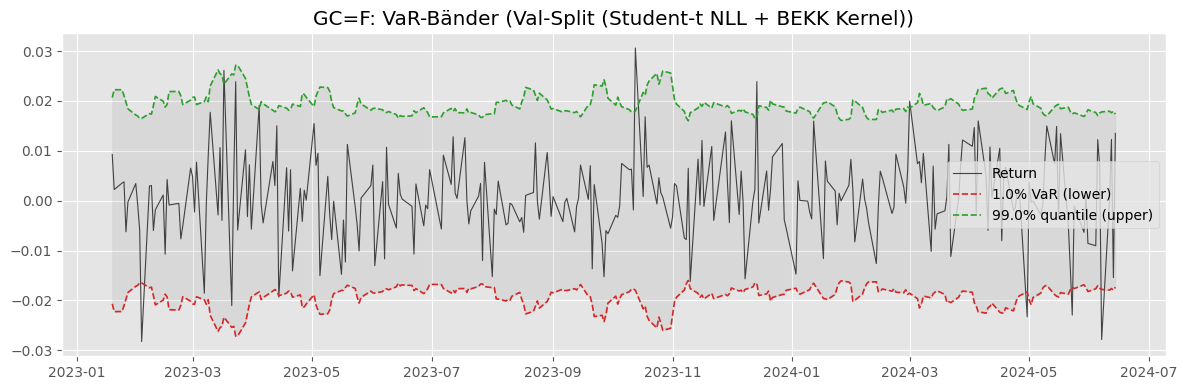

GC=F: hit rate = 1.792% (target 1.000%)


In [112]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Val-Split (Student-t NLL + BEKK Kernel)", df=val_df, pred_vol=sigma_val_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

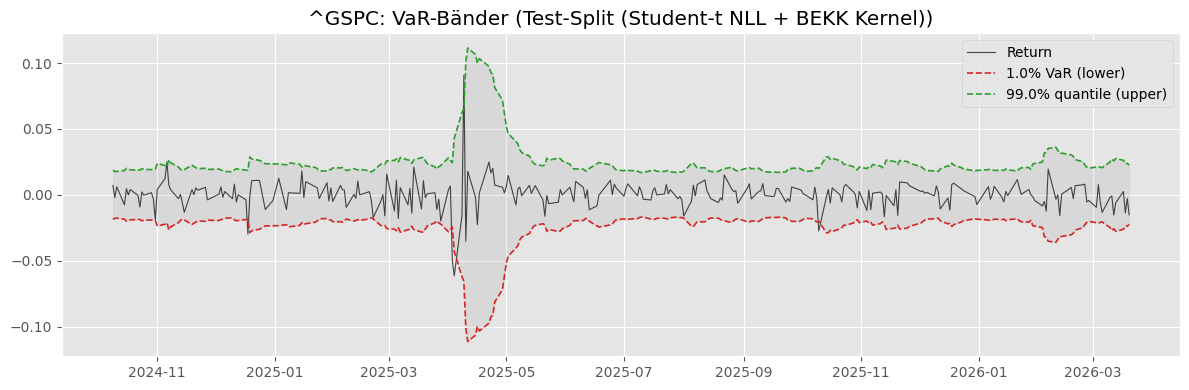

^GSPC: hit rate = 1.434% (target 1.000%)


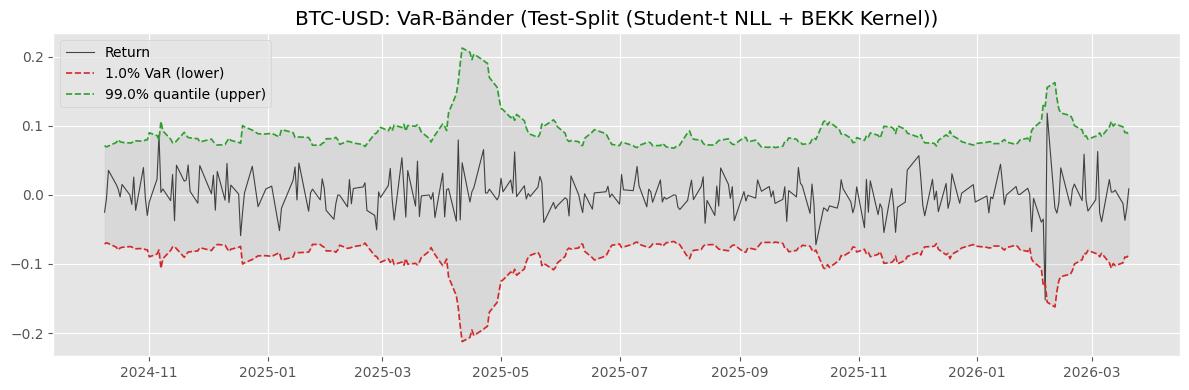

BTC-USD: hit rate = 0.358% (target 1.000%)


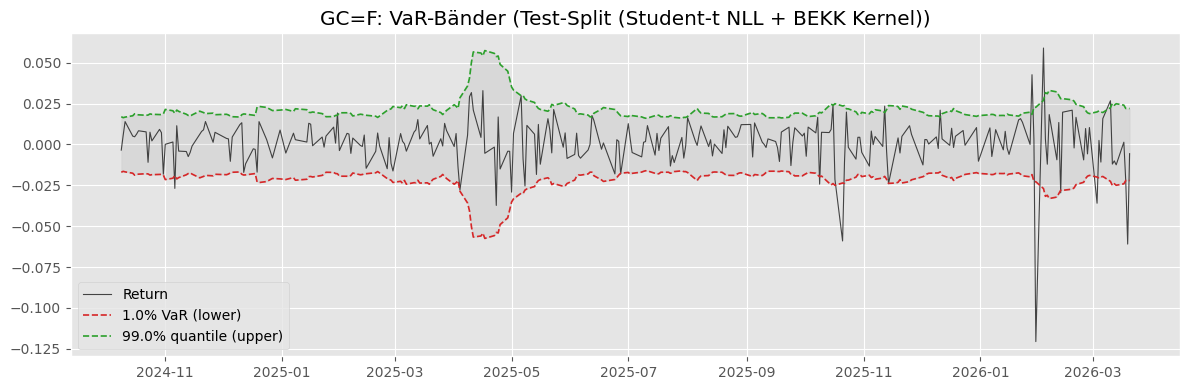

GC=F: hit rate = 3.584% (target 1.000%)


In [113]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Test-Split (Student-t NLL + BEKK Kernel)", df=test_df, pred_vol=sigma_test_real_bekk, loss_fn=student_nll, loss_kwargs=loss_kwargs)

## Portfolio

In [118]:
idx_test_bekk, rp_test_bekk, varp_test_bekk, volp_test_bekk = calc_portfolio_variance(
    test_df, sigma_test_real_bekk, feature_cols, lookback, w
)

idx_val_bekk, rp_val_bekk, varp_val_bekk, volp_val_bekk = calc_portfolio_variance(
    val_df, sigma_val_real_bekk, feature_cols, lookback, w
)

idx_train_bekk, rp_train_bekk, varp_train_bekk, volp_train_bekk = calc_portfolio_variance(
    train_df, sigma_train_real_bekk, feature_cols, lookback, w
)

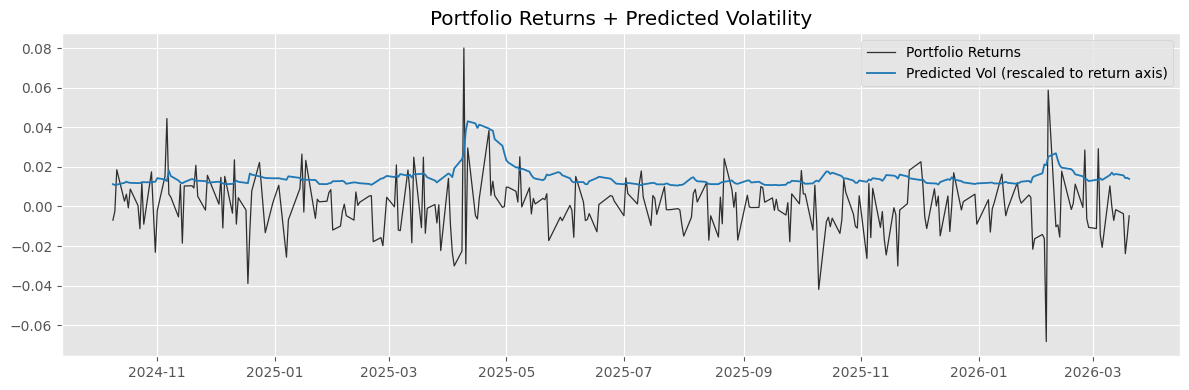

In [119]:
r = np.asarray(rp_test_bekk, dtype=float)
v = np.asarray(volp_test_bekk, dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(idx_test_bekk, r, label="Portfolio Returns", color="black", lw=0.9, alpha=0.8)
plt.plot(idx_test_bekk, v, label="Predicted Vol (rescaled to return axis)", color="tab:blue", lw=1.3)
plt.title("Portfolio Returns + Predicted Volatility")
plt.legend()
plt.tight_layout()
plt.show()

In [120]:
portfolio_test_bekk = make_portfolio_df(idx_test_bekk, rp_test_bekk, varp_test_bekk, volp_test_bekk)
portfolio_val_bekk = make_portfolio_df(idx_val_bekk, rp_val_bekk, varp_val_bekk, volp_val_bekk)
portfolio_train_bekk = make_portfolio_df(idx_train_bekk, rp_train_bekk, varp_train_bekk, volp_train_bekk)

## FHS

In [128]:
z_train_bekk = portfolio_train_bekk["r_p"].values / np.clip(portfolio_train_bekk["vol_p"].values, 1e-12, None) # clip sichert nur nach unten ab (0 division)
z_val_bekk = portfolio_val_bekk["r_p"].values / np.clip(portfolio_val_bekk["vol_p"].values, 1e-12, None)
z_test_bekk = portfolio_test_bekk["r_p"].values / np.clip(portfolio_test_bekk["vol_p"].values, 1e-12, None)
z_train_val_bekk =np.concatenate([z_train_bekk, z_val_bekk])


var_fhs_test_bekk, es_fhs_test_bekk, hits_test_bekk = fhs_var_es(
    z_hist_init=z_train_val_bekk, # nimmt die letzen #window Werte als Historie
    r_oos=portfolio_test_bekk["r_p"].values,
    vol_oos=portfolio_test_bekk["vol_p"].values,
    alpha=alpha,
    window=window
)

hit_rate_test_bekk = hits_test_bekk.mean()
print(f"FHS Test hit rate = {hit_rate_test_bekk:.3%} (target {alpha:.3%})")

FHS Test hit rate = 5.018% (target 5.000%)


# Backtesting

!!! Backtestings müssen mit dem selben $\alpha$ vorgenommen werden wie mit FHS !!!

Backtests sind für univariate Zeitreihen definiert, d.h. wir testen alle Modelle im Kontext eines vordefinierten Portfolios.

In [100]:
from backtesting import run_backtest_suite

In [129]:
results = run_backtest_suite(
    returns=portfolio_test["r_p"].values,
    var=var_fhs_test,
    es=es_fhs_test,
    alpha=alpha,
    volatility=portfolio_test["vol_p"].values,  # optional, aber für CC/ER sinnvoll
)

results

{'meta': {'alpha': 0.05, 'n_obs': 279},
 'cc': {'pvalue_twosided_simple': 0.6097050219965849,
  'pvalue_onesided_simple': 0.5472512232555249,
  'pvalue_twosided_general': 0.5758495652983329,
  'pvalue_onesided_general': 0.7600711434104511,
  'n_obs': 279},
 'er': {'pvalue_twosided_simple': 0.688,
  'pvalue_onesided_simple': 0.448,
  'pvalue_twosided_standardized': 0.716,
  'pvalue_onesided_standardized': 0.464,
  'n_obs': 279},
 'esr': {'v1': {'pvalue_twosided_asymptotic': 0.12092530229515996,
   'pvalue_twosided_bootstrap': -2147483648,
   'version': 1,
   'n_obs': 279,
   'cov_config': {'sparsity': 'iid', 'sigma_est': 'scl_sp', 'misspec': True}},
  'v2': {'pvalue_twosided_asymptotic': 0.1142379218920403,
   'pvalue_twosided_bootstrap': -2147483648,
   'version': 2,
   'n_obs': 279,
   'cov_config': {'sparsity': 'iid', 'sigma_est': 'scl_sp', 'misspec': True}},
  'v3': {'pvalue_twosided_asymptotic': 0.6368808744258307,
   'pvalue_twosided_bootstrap': -2147483648,
   'pvalue_onesided_as

In [130]:
results_student = run_backtest_suite(
    returns=portfolio_test_t["r_p"].values,
    var=var_fhs_test_t,
    es=es_fhs_test_t,
    alpha=alpha,
    volatility=portfolio_test_t["vol_p"].values,
)

results_student

{'meta': {'alpha': 0.05, 'n_obs': 279},
 'cc': {'pvalue_twosided_simple': 0.662604933251215,
  'pvalue_onesided_simple': 0.5472512232555209,
  'pvalue_twosided_general': 0.8034294624105517,
  'pvalue_onesided_general': 0.7600711434104456,
  'n_obs': 279},
 'er': {'pvalue_twosided_simple': 0.864,
  'pvalue_onesided_simple': 0.626,
  'pvalue_twosided_standardized': 0.851,
  'pvalue_onesided_standardized': 0.606,
  'n_obs': 279},
 'esr': {'v1': {'pvalue_twosided_asymptotic': 0.4287440279211199,
   'pvalue_twosided_bootstrap': -2147483648,
   'version': 1,
   'n_obs': 279,
   'cov_config': {'sparsity': 'iid', 'sigma_est': 'scl_sp', 'misspec': True}},
  'v2': {'pvalue_twosided_asymptotic': 0.5302230113621128,
   'pvalue_twosided_bootstrap': -2147483648,
   'version': 2,
   'n_obs': 279,
   'cov_config': {'sparsity': 'iid', 'sigma_est': 'scl_sp', 'misspec': True}},
  'v3': {'pvalue_twosided_asymptotic': 0.6249851656020193,
   'pvalue_twosided_bootstrap': -2147483648,
   'pvalue_onesided_asym

In [131]:
results_bekk = run_backtest_suite(
    returns=portfolio_test_bekk["r_p"].values,
    var=var_fhs_test_bekk,
    es=es_fhs_test_bekk,
    alpha=alpha,
    volatility=portfolio_test_bekk["vol_p"].values,
)

results_bekk

{'meta': {'alpha': 0.05, 'n_obs': 279},
 'cc': {'pvalue_twosided_simple': 0.5521630908054139,
  'pvalue_onesided_simple': 1.0,
  'pvalue_twosided_general': 0.3366793802936947,
  'pvalue_onesided_general': 1.0,
  'n_obs': 279},
 'er': {'pvalue_twosided_simple': 0.626,
  'pvalue_onesided_simple': 0.77,
  'pvalue_twosided_standardized': 0.429,
  'pvalue_onesided_standardized': 0.822,
  'n_obs': 279},
 'esr': {'v1': {'pvalue_twosided_asymptotic': 0.9126544543711183,
   'pvalue_twosided_bootstrap': -2147483648,
   'version': 1,
   'n_obs': 279,
   'cov_config': {'sparsity': 'iid', 'sigma_est': 'scl_sp', 'misspec': True}},
  'v2': {'pvalue_twosided_asymptotic': 0.9082912168452362,
   'pvalue_twosided_bootstrap': -2147483648,
   'version': 2,
   'n_obs': 279,
   'cov_config': {'sparsity': 'iid', 'sigma_est': 'scl_sp', 'misspec': True}},
  'v3': {'pvalue_twosided_asymptotic': 0.6010209780222338,
   'pvalue_twosided_bootstrap': -2147483648,
   'pvalue_onesided_asymptotic': 0.6994895109888831,
 